# 1. Setup

In [1]:
import os
for root, _, files in os.walk('/kaggle/input'):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/competitions/linking-writing-processes-to-writing-quality/sample_submission.csv
/kaggle/input/competitions/linking-writing-processes-to-writing-quality/test_logs.csv
/kaggle/input/competitions/linking-writing-processes-to-writing-quality/train_scores.csv
/kaggle/input/competitions/linking-writing-processes-to-writing-quality/train_logs.csv


In [2]:
import re
import string
import copy
import pickle
import numpy as np
import pandas as pd
import polars as pl
from collections import Counter

# Scipy
import scipy
import scipy.sparse
import scipy.stats
from scipy.stats import skew
from scipy.optimize import minimize

# Sklearn: modelling & preprocessing
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Boosting models
import lightgbm as lgb
from lightgbm import LGBMRegressor, LGBMClassifier, log_evaluation
import xgboost as xgb
from catboost import CatBoostRegressor

# Hyperparameter optimization
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import warnings
warnings.filterwarnings("ignore")

SEED = 42
PATH = '/kaggle/input/competitions/linking-writing-processes-to-writing-quality/'

# EDA

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df_train_logs = pd.read_csv("/kaggle/input/competitions/linking-writing-processes-to-writing-quality/train_logs.csv")
df_train_logs

,id,event_id,down_time,up_time,action_time,activity,down_event,up_event,text_change,cursor_position,word_count
0,001519c8,1,4526,4557,31,Nonproduction,Leftclick,Leftclick,NoChange,0,0
1,001519c8,2,4558,4962,404,Nonproduction,Leftclick,Leftclick,NoChange,0,0
2,001519c8,3,106571,106571,0,Nonproduction,Shift,Shift,NoChange,0,0
3,001519c8,4,106686,106777,91,Input,q,q,q,1,1
4,001519c8,5,107196,107323,127,Input,q,q,q,2,1
...,...,...,...,...,...,...,...,...,...,...,...
8405893,fff05981,3615,2063944,2064440,496,Nonproduction,Leftclick,Leftclick,NoChange,1031,240
8405894,fff05981,3616,2064497,2064497,0,Nonproduction,Shift,Shift,NoChange,1031,240
8405895,fff05981,3617,2064657,2064765,108,Replace,q,q,q => q,1031,240
8405896,fff05981,3618,2069186,2069259,73,Nonproduction,Leftclick,Leftclick,NoChange,1028,240


In [5]:
df_train_scores = pd.read_csv("/kaggle/input/competitions/linking-writing-processes-to-writing-quality/train_scores.csv")
df_train_scores

,id,score
0,001519c8,3.5
1,0022f953,3.5
2,0042269b,6.0
3,0059420b,2.0
4,0075873a,4.0
...,...,...
2466,ffb8c745,3.5
2467,ffbef7e5,4.0
2468,ffccd6fd,1.5
2469,ffec5b38,5.0


score distribution

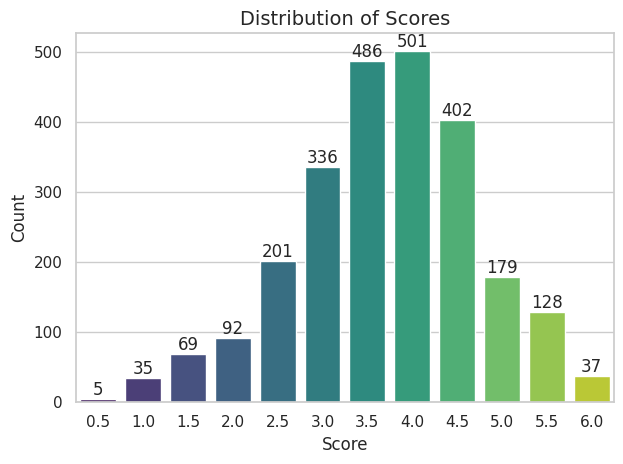

In [6]:
# Prepare data
score_counts = df_train_scores['score'].value_counts().sort_index()

# Set style
sns.set(style="whitegrid")

# Create plot
sns.barplot(
    x=score_counts.index,
    y=score_counts.values,
    palette='viridis'
)
for i, v in enumerate(score_counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')

# Labels and title
plt.title('Distribution of Scores', fontsize=14)
plt.xlabel('Score')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [7]:
df_train_scores['score'].describe()

count    2471.000000
mean        3.711251
std         1.024937
min         0.500000
25%         3.000000
50%         4.000000
75%         4.500000
max         6.000000
Name: score, dtype: float64

events per essay vs score

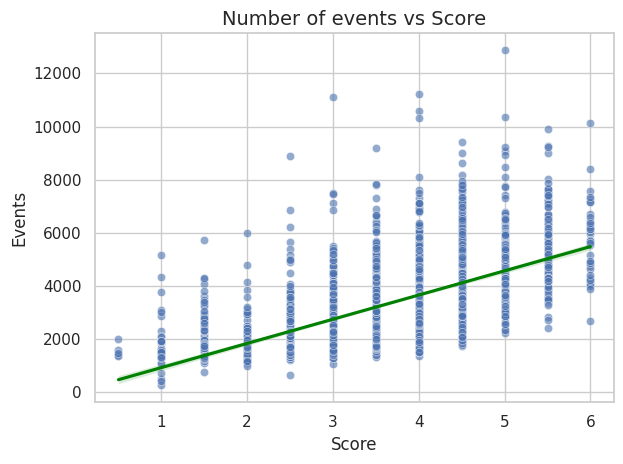

In [8]:
# Prepare data
x = df_train_scores.set_index('id')['score']
y = df_train_logs['id'].value_counts()

df_plot = x.to_frame('score').join(y.rename('events'), how='inner')

# Set seaborn style
sns.set(style="whitegrid")

# Create plot
# plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_plot,
    x='score',
    y='events',
    alpha=0.6
)
sns.regplot(
    data=df_plot,
    x='score',
    y='events',
    scatter=False,
    color='green'
)

# Labels and title
plt.title('Number of events vs Score', fontsize=14)
plt.xlabel('Score')
plt.ylabel('Events')

plt.tight_layout()
plt.show()

events_per_essay = y

final word count vs score

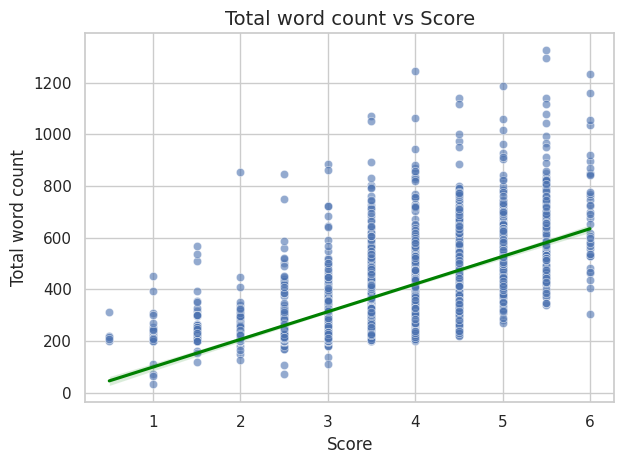

In [9]:
# Prepare data
x = df_train_scores.set_index('id')['score']
y = df_train_logs.groupby(["id"])['word_count'].max()

df_plot = x.to_frame('score').join(y.rename('word_count'), how='inner')

# Set seaborn style
sns.set(style="whitegrid")

# Create plot
# plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_plot,
    x='score',
    y='word_count',
    alpha=0.6
)
sns.regplot(
    data=df_plot,
    x='score',
    y='word_count',
    scatter=False,
    color='green'
)

# Labels and title
plt.title('Total word count vs Score', fontsize=14)
plt.xlabel('Score')
plt.ylabel('Total word count')

plt.tight_layout()
plt.show()

final_word_count = y

total duration vs score

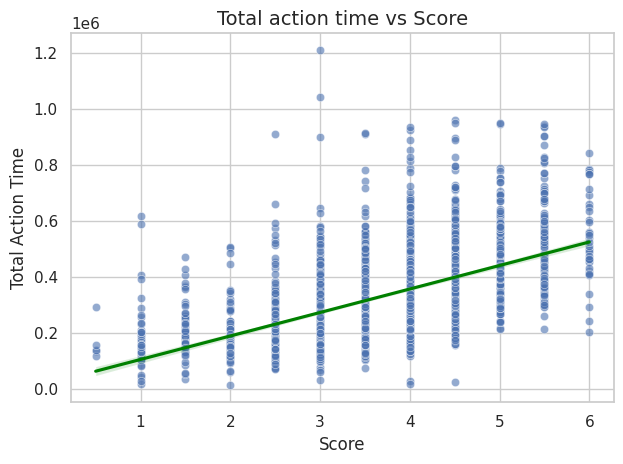

In [10]:
# Prepare data
x = df_train_scores.set_index('id')['score']
y = df_train_logs.groupby(["id"])['action_time'].sum()

df_plot = x.to_frame('score').join(y.rename('total_action_time'), how='inner')

# Set seaborn style
sns.set(style="whitegrid")

# Create plot
# plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_plot,
    x='score',
    y='total_action_time',
    alpha=0.6
)
sns.regplot(
    data=df_plot,
    x='score',
    y='total_action_time',
    scatter=False,
    color='green'
)

# Labels and title
plt.title('Total action time vs Score', fontsize=14)
plt.xlabel('Score')
plt.ylabel('Total Action Time')

plt.tight_layout()
plt.show()

total_action_time = y

editing rate vs score

In [11]:
df_train_logs['activity'].value_counts()

activity
Input                                     6726796
Remove/Cut                                 970158
Nonproduction                              703851
Replace                                      4448
Paste                                         599
Move From [1306, 1371] To [1061, 1126]          2
Move From [287, 289] To [285, 287]              1
Move From [460, 461] To [465, 466]              1
Move From [905, 1314] To [907, 1316]            1
Move From [284, 292] To [282, 290]              1
Move From [669, 847] To [565, 743]              1
Move From [1041, 1121] To [1496, 1576]          1
Move From [1455, 1557] To [1323, 1425]          1
Move From [2268, 2275] To [2247, 2254]          1
Move From [213, 302] To [902, 991]              1
Move From [0, 158] To [234, 392]                1
Move From [460, 465] To [925, 930]              1
Move From [565, 743] To [669, 847]              1
Move From [810, 906] To [816, 912]              1
Move From [186, 187] To [184, 185]       

In [12]:
# define editing rate as (Remove/Cut + Replace + Paste)/Input. essentially, "how much does this writer edit their writing"

input_counts = (df_train_logs[df_train_logs['activity'] == 'Input'].groupby('id').size())
remove_counts = (df_train_logs[df_train_logs['activity'] == 'Remove/Cut'].groupby('id').size())
replace_counts = (df_train_logs[df_train_logs['activity'] == 'Replace'].groupby('id').size())
paste_counts = (df_train_logs[df_train_logs['activity'] == 'Paste'].groupby('id').size())

In [13]:
# Combine into one DataFrame
editing_ratio = (
    input_counts.rename('Input')
    .to_frame()
    .join(remove_counts.rename('Remove/Cut'))
    .join(replace_counts.rename('Replace'))
    .join(paste_counts.rename('Paste'))
    .fillna(0)
)

# Compute ratio
editing_ratio['edit_ratio'] = (
    (editing_ratio['Remove/Cut'] + editing_ratio['Replace'] + editing_ratio['Paste']) 
    / editing_ratio['Input']
)

# handle division by zero. for input_counts=0, ratio should be 0
editing_ratio['edit_ratio'] = editing_ratio['edit_ratio'].replace([float('inf')], 0)

editing_ratio

,Input,Remove/Cut,Replace,Paste,edit_ratio
id,,,,,
001519c8,2010,417.0,7.0,0.0,0.210945
0022f953,1938,260.0,1.0,1.0,0.135191
0042269b,3515,439.0,7.0,0.0,0.126885
0059420b,1304,151.0,1.0,1.0,0.117331
0075873a,1942,517.0,0.0,0.0,0.266220
...,...,...,...,...,...
ffb8c745,3588,960.0,2.0,0.0,0.268116
ffbef7e5,2395,60.0,1.0,0.0,0.025470
ffccd6fd,2849,88.0,0.0,0.0,0.030888


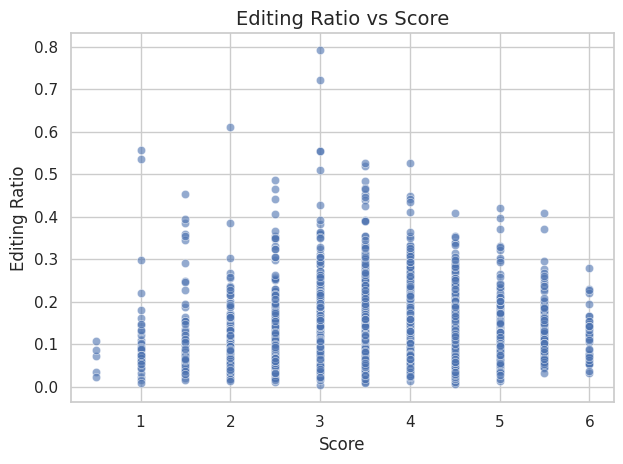

In [14]:
# Prepare data
x = df_train_scores.set_index('id')['score']
y = editing_ratio['edit_ratio']

df_plot = x.to_frame('score').join(y.rename('editing_ratio'), how='inner')

# Set seaborn style
sns.set(style="whitegrid")

# Create plot
# plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_plot,
    x='score',
    y='editing_ratio',
    alpha=0.6
)

# Labels and title
plt.title('Editing Ratio vs Score', fontsize=14)
plt.xlabel('Score')
plt.ylabel('Editing Ratio')

plt.tight_layout()
plt.show()

editing_ratio = y

total useless keystrokes vs score

In [15]:
df_train_logs['down_event'].unique()

array(['Leftclick', 'Shift', 'q', 'Space', 'Backspace', '.', ',', 'Enter',
       'ArrowLeft', "'", ';', 'ArrowRight', '-', '?', 'Tab', '"',
       'ArrowUp', 'ArrowDown', 'Rightclick', '=', 'CapsLock', 'Control',
       'c', 'v', '/', 'Delete', ':', 'z', '[', '$', '(', ')', '+', 'Home',
       'End', '\\', 'Meta', '*', '&', 'AudioVolumeMute', 'x', '!',
       'Insert', 'MediaPlayPause', 'NumLock', '%', 'V', '>', 'Alt',
       'AudioVolumeUp', 'ContextMenu', 'AudioVolumeDown', 'a', '<',
       'PageDown', ']', 'Middleclick', '@', 'F12', 'j', '\x96', 'Dead',
       't', 's', 'n', 'y', '{', 'ScrollLock', '¿', 'Process', '}',
       'MediaTrackPrevious', 'MediaTrackNext', 'F3', '^', 'Unidentified',
       'Cancel', '2', 'i', 'd', 'r', 'e', '`', '\x9b', 'm', '#', '~',
       'PageUp', 'T', 'A', 'b', 'S', 'ModeChange', '_', 'Escape', 'F11',
       'Unknownclick', 'AltGraph', 'F10', 'h', 'F15', 'Clear', 'OS', 'F',
       'C', 'o', 'Ä±', 'f', 'u', 'w', 'p', 'g', 'M', 'l', '|',
       'â\x80\x

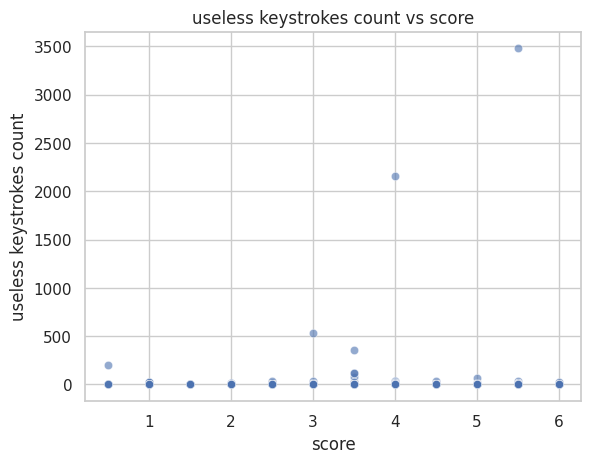

In [16]:
useless_keystrokes = ['\\', 'Meta', 'AudioVolumeMute', 'MediaPlayPause', 'Alt', 'AudioVolumeUp', 'ContextMenu', 'AudioVolumeDown', 'PageDown', 'Middleclick', 'F1', 'F2', 'F3', 
                      'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10', 'F11', 'F12', '\x96', 'Dead', 'ScrollLock', '¿', 'Process', 'Pause', 'ä', 'Å\x9f', 'Â', '\x80', 'Ë\x86', '\x97', 
                      'â\x80\x93', 'Ä±', 'OS', 'Clear', 'AltGraph', 'Unknownclick', 'Escape', 'ModeChange', 'PageUp', '\x9b', 'Cancel', 'Unidentified', 'MediaTrackNext', 'MediaTrackPrevious']

# Prepare data
x = df_train_scores.set_index('id')['score']
y = (df_train_logs['down_event'].isin(useless_keystrokes).groupby(df_train_logs['id']).sum())
df_plot = x.to_frame('score').join(y.rename('useless_keystrokes'), how='inner')

# Align indices if needed (important!)
# This ensures x and y correspond to the same essays
y = y.sort_index()
x = x.sort_index()

# Create scatter plot
plt.figure()
sns.scatterplot(
    data=df_plot,
    x='score',
    y='useless_keystrokes',
    alpha=0.6
)

# Labels and title
plt.xlabel('score')
plt.ylabel('useless keystrokes count')
plt.title('useless keystrokes count vs score')

# Show plot
plt.show()

useless_keystrokes_count = y

everything correlation vs score

In [17]:
# Combine all features into one DataFrame
df_features = pd.DataFrame({
    'score': df_train_scores.set_index('id')['score'],
    'events_per_essay': events_per_essay,
    'final_word_count': final_word_count,
    'total_action_time': total_action_time,
    'editing_ratio': editing_ratio,
    'useless_keystrokes': useless_keystrokes_count
})

# Compute correlation matrix
corr = df_features.corr()

corr

,score,events_per_essay,final_word_count,total_action_time,editing_ratio,useless_keystrokes
score,1.000000,0.590769,0.635948,0.545614,0.008394,0.026947
events_per_essay,0.590769,1.000000,0.801048,0.851831,0.330515,0.057445
final_word_count,0.635948,0.801048,1.000000,0.744757,-0.104543,0.012374
total_action_time,0.545614,0.851831,0.744757,1.000000,0.261047,0.034426
editing_ratio,0.008394,0.330515,-0.104543,0.261047,1.000000,-0.024109
useless_keystrokes,0.026947,0.057445,0.012374,0.034426,-0.024109,1.000000


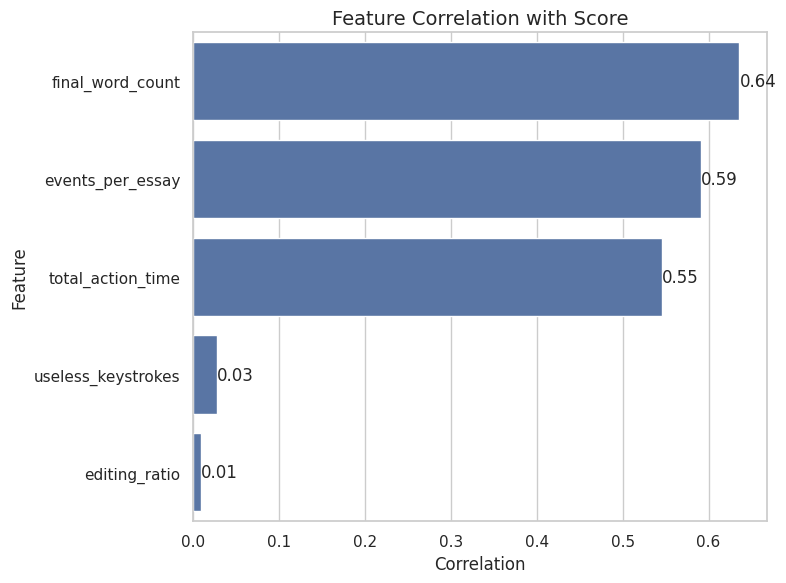

In [18]:
# Prepare data
corr_with_score = df_features.corr()['score'].drop('score').sort_values(ascending=False)

# Set seaborn style
sns.set(style="whitegrid")

# Create plot
plt.figure(figsize=(8, 6))
sns.barplot(
    x=corr_with_score.values,
    y=corr_with_score.index,
)
for i, v in enumerate(corr_with_score.values):
    plt.text(v, i, f"{v:.2f}", va='center')

# Labels and title
plt.title('Feature Correlation with Score', fontsize=14)
plt.xlabel('Correlation')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [19]:
df_train_logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8405898 entries, 0 to 8405897
Data columns (total 11 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   id               object
 1   event_id         int64 
 2   down_time        int64 
 3   up_time          int64 
 4   action_time      int64 
 5   activity         object
 6   down_event       object
 7   up_event         object
 8   text_change      object
 9   cursor_position  int64 
 10  word_count       int64 
dtypes: int64(6), object(5)
memory usage: 705.5+ MB


## Cluster analysis

In [20]:
# Sort for safety
df = df_train_logs.sort_values(['id', 'event_id'])

# Cursor movement
df['cursor_move'] = df.groupby('id')['cursor_position'].diff().fillna(0)

# Activity flags
activities = ['Input', 'Remove/Cut', 'Paste', 'Replace', 'Nonproduction']
for act in activities:
    df[f'act_{act}'] = (df['activity'] == act).astype(int)

# Aggregate per essay
agg_dict = {
    'event_id': 'count',
    'action_time': ['sum', 'mean', 'max'],
    'cursor_move': ['mean', 'std'],
    'word_count': 'max',
}

# Add activity counts
for act in activities:
    agg_dict[f'act_{act}'] = 'sum'

df_essay = df.groupby('id').agg(agg_dict)

# Flatten columns
df_essay.columns = ['_'.join(col).strip() for col in df_essay.columns]
df_essay = df_essay.reset_index()

# Derived features
df_essay['events_per_second'] = df_essay['event_id_count'] / (df_essay['action_time_sum'] + 1)

In [21]:
df_final = df_essay.merge(df_train_scores, on='id')

In [22]:
from sklearn.preprocessing import StandardScaler

feature_cols = [col for col in df_final.columns if col not in ['id', 'score']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_final[feature_cols])

- Whether essays naturally group into styles
- Whether clusters align with score
- If clusters separate cleanly by score → strong behavioral signal

In [23]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df_final['cluster'] = kmeans.fit_predict(X_scaled)

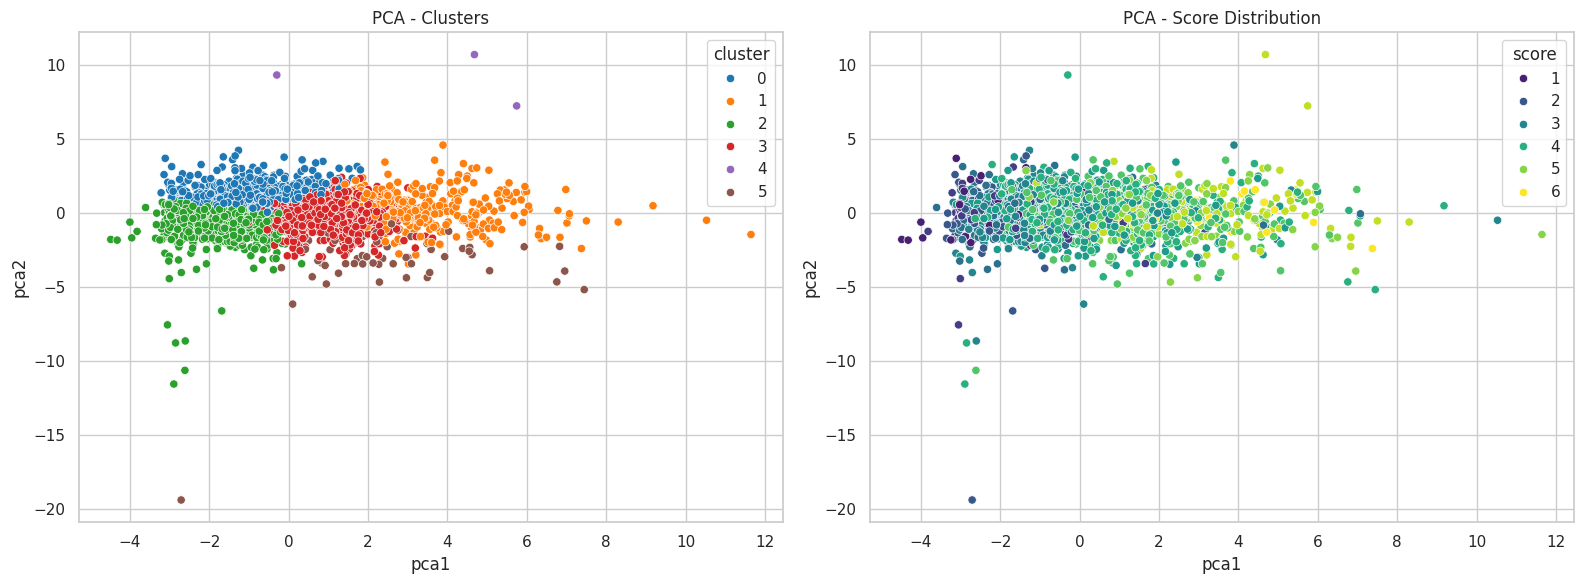

In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_final['pca1'] = X_pca[:, 0]
df_final['pca2'] = X_pca[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Plot 1: clusters
sns.scatterplot(
    data=df_final,
    x='pca1', y='pca2',
    hue='cluster',
    palette='tab10',
    ax=axes[0]
)
axes[0].set_title('PCA - Clusters')
# Plot 2: score
sns.scatterplot(
    data=df_final,
    x='pca1', y='pca2',
    hue='score',
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('PCA - Score Distribution')

plt.tight_layout()
plt.show()

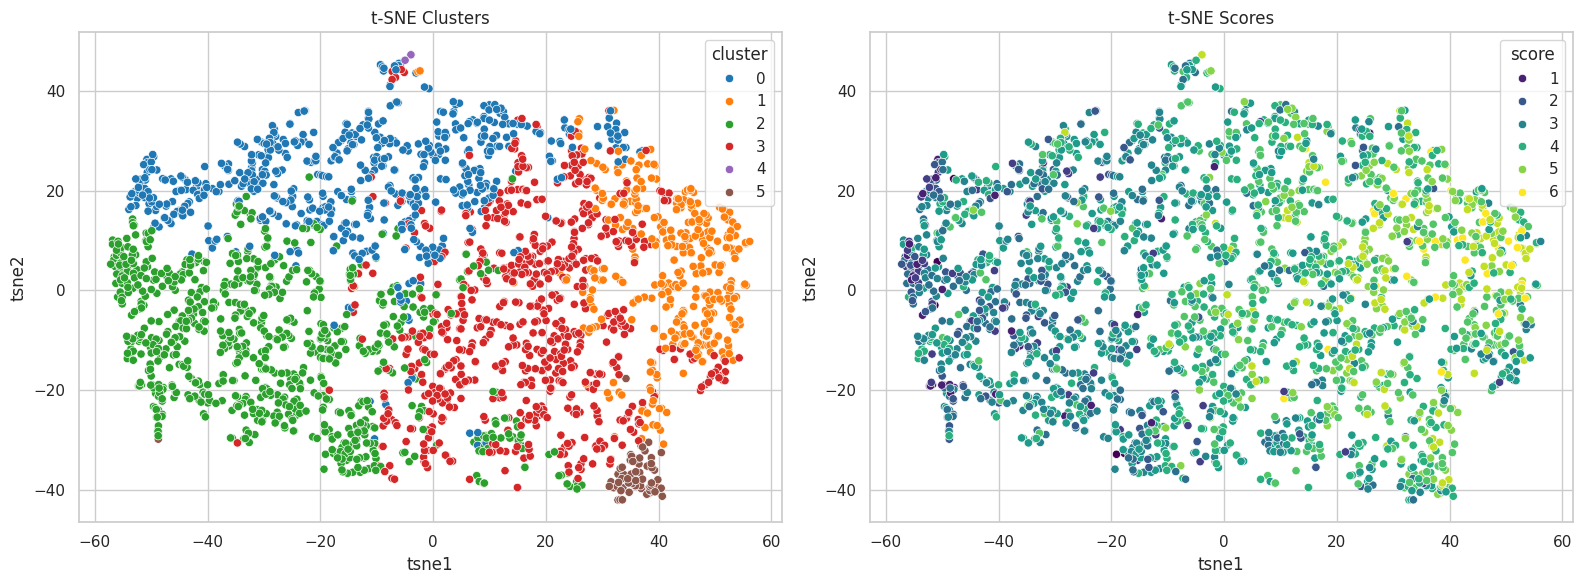

In [25]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)  # sample for speed

df_final['tsne1'] = X_tsne[:, 0]
df_final['tsne2'] = X_tsne[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Plot 1: clusters
sns.scatterplot(
    data=df_final,
    x='tsne1', y='tsne2',
    hue='cluster',
    palette='tab10',
    ax=axes[0]
)
axes[0].set_title('t-SNE Clusters')
# Plot 2: score
sns.scatterplot(
    data=df_final,
    x='tsne1', y='tsne2',
    hue='score',
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('t-SNE Scores')

plt.tight_layout()
plt.show()

Behavioral archetypes exist and are structurally coherent, but they are not strong deterministic predictors of score on their own. The clusters capture writing style more than writing quality. This is important — it means cluster membership may be a useful feature but should not be over-relied upon.

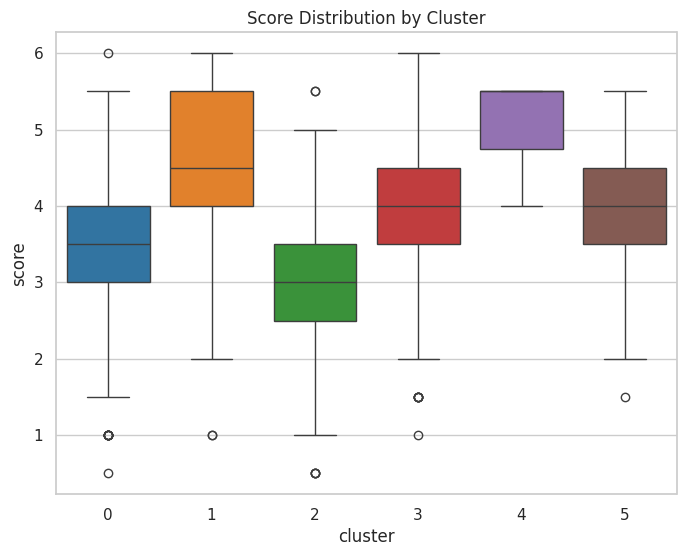

In [26]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df_final, x='cluster', y='score', palette='tab10')
plt.title('Score Distribution by Cluster')
plt.show()

The current feature set captures between-writer differences in writing volume and session length well, but does not yet encode the within-session behavioral dynamics and compositional nuances that plausibly drive quality. Further feature decomposition is needed to surface those patterns.

# 2. Feature Engineering

## 2.1 Essay Reconstruction
Replay the keystroke log actions in sequence to recover the final submitted essay.

In [27]:
def replay_keystrokes(group):
    """
    Reconstruct the final essay from a writer's keystroke log
    by replaying each editing action in sequence.
    """
    uid = group["id"].iloc[0]
    essay = ""

    def _input(essay, cursor, change):
        start = cursor - len(change)
        return essay[:start] + change + essay[start:]

    def _remove(essay, cursor, change):
        return essay[:cursor] + essay[cursor + len(change):]

    def _paste(essay, cursor, change):
        start = cursor - len(change)
        return essay[:start] + change + essay[start:]

    def _replace(essay, cursor, change):
        before, after = change.split(" => ")
        start = cursor - len(after)
        return essay[:start] + after + essay[start + len(before):]

    def _move(essay, cursor, change, activity):
        span_str = activity[10:]
        src, dst = [p.split(", ") for p in span_str.split(" To ")]
        s1, e1 = int(src[0][1:]), int(src[1][:-1])
        s2, e2 = int(dst[0][1:]), int(dst[1][:-1])
        if s1 < s2:
            return essay[:s1] + essay[e1:e2] + essay[s1:e1] + essay[e2:]
        return essay[:s2] + essay[s1:e1] + essay[s2:s1] + essay[e1:]

    log = group[group["activity"] != "Nonproduction"][
        ["activity", "cursor_position", "text_change"]
    ].values

    for activity, cursor, change in log:
        if activity == "Replace":
            essay = _replace(essay, cursor, change)
        elif activity == "Paste":
            essay = _paste(essay, cursor, change)
        elif activity == "Remove/Cut":
            essay = _remove(essay, cursor, change)
        elif "M" in activity:
            essay = _move(essay, cursor, change, activity)
        else:
            essay = _input(essay, cursor, change)

    return uid, essay

## 2.2 Text Feature Engineering

In [28]:
def normalise_whitespace(text):
    """Strip tabs, collapse multiple spaces/newlines."""
    for pattern, replacement in [
        (r"\t", ""),
        (r"\n +", "\n"),
        (r" +\n", "\n"),
        (r"\n{2,}", "\n"),
        (r" {2,}", " "),
    ]:
        text = re.sub(pattern, replacement, text)
    return text.strip()

In [29]:
def split_to_word(s, mode='original'):
    s = s.lower()
    if mode == 'original':
        s_arr = re.split(' ', s)
    else:
        char_sep = '@'
        for punc in [' ', ',', '"', '.', '(', ')', '[', ']', '{', '}', '!', '?']:
            s = s.replace(punc, char_sep)
        s_arr = re.split(char_sep, s)
    s_arr = [w for w in s_arr if 'q' in w]
    return s_arr

def split_to_sentence(s):
    s = s.lower()
    char_sep = '@'
    for punc in ['.', '!', '?']:
        s = s.replace(punc, char_sep)
    s_arr = re.split(char_sep, s)
    s_arr = [w for w in s_arr if 'q' in w]
    return s_arr

def split_to_paragraph(s):
    s = s.lower()
    char_sep = '@'
    s_arr = re.split(char_sep, s)
    s_arr = [w for w in s_arr if 'q' in w]
    return s_arr

In [30]:
def surface_features(df):
    df["text_length"] = df["essay"].apply(len)
    df["num_newlines"] = df["essay"].apply(lambda x: x.count("\n"))

    df["repetitiveness"] = df["essay"].apply(lambda x: x.count("q")/max(1, len(x)))
    df["word_count"] = df["essay"].apply(lambda x: len(x.split()))
    df["avg_word_length"] = df["essay"].apply(
        lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0)
    df["word_lexical_diversity"] = df["essay"].apply(
        lambda x: len(set(x.split())) / len(x.split()) if x.split() else 0)
    return df

In [31]:
def q25(x): return x.quantile(0.25)
def q75(x): return x.quantile(0.75)

def agg_stats(series_df, group_col, value_col, prefix):
    agg = (
        series_df.groupby(group_col)[value_col]
        .agg(["count", "min", "max", "median", "std", "sum", "first", "last", q25, q75]))
    agg.columns = [f"{prefix}_{c}" for c in
                   ["count","min","max","median","std","sum","first","last","q25","q75"]]
    return agg.reset_index()

In [32]:
def word_level_stats(df):
    """Length distribution across individual words."""
    tmp = df[["id", "essay"]].copy()
    tmp["token"] = tmp["essay"].apply(lambda x: re.split(r"[ \n.!?]", x))
    tmp = tmp.explode("token")
    tmp["tok_len"] = tmp["token"].apply(len)
    tmp = tmp[tmp["tok_len"] > 0]
    return agg_stats(tmp, "id", "tok_len", "word_len")

In [33]:
def sentence_level_stats(df):
    """Length and word-count distribution across sentences."""
    tmp = df[["id", "essay"]].copy()
    tmp["sent"] = tmp["essay"].apply(lambda x: re.split(r"[.!?]", x))
    tmp = tmp.explode("sent")
    tmp["sent"] = tmp["sent"].str.strip()
    tmp = tmp[tmp["sent"].apply(len) > 0]
    tmp["sent_len"] = tmp["sent"].apply(len)
    tmp["sent_wc"] = tmp["sent"].apply(lambda x: len(x.split()))

    agg_len = agg_stats(tmp, "id", "sent_len", "sent_len")
    agg_wc = agg_stats(tmp, "id", "sent_wc", "sent_wc")
    agg = agg_len.merge(agg_wc, on="id")
    agg.rename(columns={"sent_len_count": "sentence_count"}, inplace=True)
    agg.drop(columns=["sent_wc_count"], inplace=True)
    return agg

In [34]:
def paragraph_level_stats(df):
    """Length, word-count and sentence-count distribution across paragraphs.""" 
    tmp = df[["id", "essay"]].copy()
    tmp["para"] = tmp["essay"].apply(lambda x: x.split("\n"))
    tmp = tmp.explode("para")
    tmp["para"] = tmp["para"].str.strip()
    tmp = tmp[tmp["para"].apply(len) > 2] # ignore super short paras
    tmp["para_len"] = tmp["para"].apply(len)
    tmp["para_wc"] = tmp["para"].apply(lambda x: len(x.split()))
    tmp["para_sc"] = tmp["para"].apply(lambda x: len([s for s in re.split(r"[.!?]", x) if s.strip()]))

    agg_len = agg_stats(tmp, "id", "para_len", "para_len")
    agg_wc = agg_stats(tmp, "id", "para_wc", "para_wc")
    agg_sc = agg_stats(tmp, "id", "para_sc", "para_sc")
    agg = agg_len.merge(agg_wc, on="id").merge(agg_sc, on="id")
    agg.rename(columns={"para_len_count": "para_count"}, inplace=True)
    agg.drop(columns=["para_wc_count", "para_sc_count"], inplace=True)
    return agg

In [35]:
def grammar_surface_errors(text):
    """
    Grammar surface checks: returns a dict of error counts.
    """
    if not isinstance(text, str) or not text:
        return {k: 0 for k in [
            "space_before_comma", "space_before_period",
            "missing_space_after_comma", "missing_space_after_period",
            "repeated_punct", "total_errors"
        ]}

    patterns = {
        "space_before_comma": r" ,",
        "space_before_period": r" \.",
        "missing_space_after_comma": r",[a-zA-Z]",
        "missing_space_after_period": r"\.[a-zA-Z]",
        "repeated_punct": r"[!?.,]{2,}",
    }
    counts = {k: len(re.findall(p, text)) for k, p in patterns.items()}
    counts["total_errors"] = sum(counts.values())
    return counts

In [36]:
def typo_prob(text):
    """
    Typo probability: ratio of 3+ consecutive consonant runs to text length.
    - pure-q tokens skipped: anonymised words
    """
    hits = re.findall(r'[bcdfghjklmnpqrstvwxyz]{3,}', text.lower())
    real_hits = [h for h in hits if not all(c == 'q' for c in h)]
    return len(real_hits) / max(1, len(text))

In [37]:
def get_reconstruction_related_feats(df):
    res, error_res = [], []
    word_length_res, words_per_sentence_res, words_per_paragraph_res = [], [], []

    for s in df.essay.values:
        res_ = [len(s)]
        words = split_to_word(s, mode='strict')
        len_words = np.array([len(w) for w in words]) if words else np.array([0])
        res_.append((len_words < 5).sum())
        for word_l in [5, 6, 7, 8, 9, 10, 11, 12]:
            res_.append((len_words >= word_l).sum())
        word_length_res.append(summarize_arr(len_words))

        sentences = split_to_sentence(s)
        len_sentences = np.array([len(w) for w in sentences]) if sentences else np.array([0])
        res_.append((len_sentences < 50).sum())
        for sent_l in [50, 60, 75, 100]:
            res_.append((len_sentences >= sent_l).sum())
        words_per_sentence = np.array(
            [len(split_to_word(w, mode='strict')) for w in sentences]) if sentences else np.array([0])
        words_per_sentence_res.append(summarize_arr(words_per_sentence))
        res.append(res_)

        paragraphs = split_to_paragraph(s)
        words_per_paragraph = np.array(
            [len(split_to_word(w, mode='strict')) for w in paragraphs]) if paragraphs else np.array([0])
        words_per_paragraph_res.append(summarize_arr(words_per_paragraph))

        s_ = copy.deepcopy(s)
        s_clean = s.lower()
        for stopword in ['q.q.q.q.q.q.', 'q.q.q.q.q.', 'q.q.q.q.', 'q.q.q.', 'q.q.',
                         '...', ' q.q ', '$q.q', '$qq.q', '$qqq.q', '$qqqq.q',
                         '$q,q', '$qq,q', '$qqq,q', '$qqqq,q',
                         ',qqq,qqq,qqq,qqq ', ',qqq,qqq,qqq ', ',qqq,qqq ', ',qqq ']:
            s_clean = s_clean.replace(stopword, '')

        res_ = []
        res_.append(len(re.findall(r' \.', s_clean)))
        res_.append(len(re.findall(r'\.q', s_clean)))
        res_.append(len(re.findall(r' \,', s_clean)))
        res_.append(len(re.findall(r'\,q', s_clean)))
        s_err = 'AAA ' + s_
        s_err = s_err.replace('.', 'AAA').replace('!', 'AAA').replace('?', 'AAA')
        res_.append(len(re.findall('AAA q', s_err)))
        error_res.append(res_)

    res = np.array(res)
    error_res = np.array(error_res)
    word_length_res = np.array(word_length_res)
    words_per_sentence_res = np.array(words_per_sentence_res)
    words_per_paragraph_res = np.array(words_per_paragraph_res)

    df['reconstructed_len'] = res[:, 0]
    for i, x in enumerate([4, 5, 6, 7, 8, 9, 10, 11, 12]):
        df[f'word_length_{x}_count'] = res[:, i+1]
    for i, x in enumerate([49, 50, 60, 75, 100]):
        df[f'sentence_length_{x}_count'] = res[:, i+10]
    for i, x in enumerate(["num", "mean", "max", "min", "std", "q05", "q25", "q50", "q75", "q95"]):
        df[f'word_length_{x}'] = word_length_res[:, i]
        df[f'words_per_sentence_{x}'] = words_per_sentence_res[:, i]
        df[f'words_per_paragraph_{x}'] = words_per_paragraph_res[:, i]
    i = 0
    for x in ['period', 'comma']:
        for y in ['before', 'after']:
            df[f'{x}_{y}_error_count'] = error_res[:, i]
            i += 1
        df[f'{x}_error_count'] = df[f'{x}_before_error_count'] + df[f'{x}_after_error_count']
    df['capitalize_error_count'] = error_res[:, i]
    df['error_count'] = error_res.sum(axis=1)
    return df

In [38]:
def run_text_pipeline(df):
    df = df.copy()

    # Replace blank essays with placeholder
    is_blank = df["essay"].str.replace(" ", "", regex=False) == ""
    df.loc[is_blank, "essay"] = "placeholder"

    df["essay"] = df["essay"].apply(normalise_whitespace)

    # Structural features
    for merge_fn in [word_level_stats, sentence_level_stats, paragraph_level_stats]:
        df = df.merge(merge_fn(df), on="id", how="left")

    # Surface features
    df = surface_features(df)

    # Grammar errors
    error_results = df["essay"].apply(grammar_surface_errors)
    for key in ["space_before_comma", "space_before_period",
                "missing_space_after_comma", "missing_space_after_period",
                "repeated_punct", "total_errors"]:
        df[key] = error_results.apply(lambda x: x[key])

    # Character counts
    char_features = {
        "comma": ",", "quote": "'", "space": " ",
        "period": ".", "exclaim": "!", "hyphen": "-", "colon": ":"
    }
    for name, ch in char_features.items():
        df[f"char_{name}"] = df["essay"].apply(lambda x: x.count(ch))

    df["typo_probability"] = df["essay"].apply(typo_prob)

    return df

## 2.3 TF-IDF Essay Features
Word and character n-gram TF-IDF reduced to 64 SVD components. Vectorisers are fit on train and reused on test.
Ridge regression on word n-grams provides an additional linear OOF signal.

In [39]:
def build_tfidf_features(texts, n_components=64, preprocessors=None):
    """
    Takes a list of essay texts, returns (array of shape [n, n_components*2], preprocessors)
    preprocessors = (word_vectorizer, char_vectorizer, svd) — pass in for test set
    """
    if preprocessors is None:
        word_vec = TfidfVectorizer(
            analyzer='word',
            ngram_range=(1, 3),
            lowercase=True,
            sublinear_tf=True,
            min_df=2
        )
        char_vec = TfidfVectorizer(
            analyzer='char',
            ngram_range=(2, 5),
            lowercase=False,
            sublinear_tf=True,
            min_df=2
        )
        word_vec.fit(texts)
        char_vec.fit(texts)
    else:
        word_vec, char_vec, svd = preprocessors

    word_feats = word_vec.transform(texts)
    char_feats = char_vec.transform(texts)
    combined = scipy.sparse.hstack([char_feats, word_feats])

    if preprocessors is None:
        svd = TruncatedSVD(n_components=n_components, n_iter=8, random_state=42)
        svd.fit(combined)

    reduced = svd.transform(combined)

    tfidf_cols = [f'tfidf_{i}' for i in range(n_components)]
    preprocessors_out = (word_vec, char_vec, svd)
    return reduced, tfidf_cols, preprocessors_out


def add_tfidf_to_df(df, n_components=64, preprocessors=None):
    texts = df["essay"].fillna('').tolist()
    reduced, tfidf_cols, preprocessors_out = build_tfidf_features(
        texts, n_components=n_components, preprocessors=preprocessors
    )
    for i, col in enumerate(tfidf_cols):
        df[col] = reduced[:, i]
    return df, preprocessors_out

In [40]:
def build_ridge_tfidf(train_texts, test_texts, target, n_splits=10, upper=6):
    """Train Ridge on TF-IDF features with CV, return OOF and test predictions."""
    
    def word_tokenize(text):
        return text.split()
    
    # Add space before period so it becomes its own token
    train_texts = train_texts.str.replace('.', ' .', regex=False)
    test_texts = test_texts.str.replace('.', ' .', regex=False)
    
    vec = TfidfVectorizer(
        tokenizer=word_tokenize,
        lowercase=True,
        token_pattern=None,
        min_df=16,
        ngram_range=(1, upper)
    )
    
    X_train = vec.fit_transform(train_texts)
    X_test = vec.transform(test_texts)
    
    ridge = Ridge(alpha=0.7)
    
    oof = np.zeros(len(target))
    test_preds = np.zeros(X_test.shape[0])
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=123)
    for tr, va in skf.split(X_train, (target * 2).astype(int)):
        ridge_fold = Ridge(alpha=0.7)
        ridge_fold.fit(X_train[tr], target[tr])
        oof[va] = ridge_fold.predict(X_test[tr] if False else X_train[va])
        test_preds += ridge_fold.predict(X_test) / n_splits
    
    print(f"Ridge TF-IDF OOF RMSE: {rmse(target, oof):.5f}")
    return oof, test_preds, vec

## 2.4 Keystroke / Writing Process Features
Two complementary feature sets over the raw keystroke log: pandas-based structural/timing features and Polars-based aggregation features.

In [41]:
def collect_bursts(log_df, max_gap_ms, min_burst_len):
    """
    Iterate through logs once and collect burst sequences per writer. Returns:
    - productive_bursts
    - rhythmic_bursts
    """
    productive_bursts_all = []
    rhythmic_bursts_all = []

    current_id = None
    current_productive = []
    current_rhythmic = []
    active_productive_run = []
    active_rhythmic_run = []
    last_down_time = 0
    last_activity = ''

    editing_activities = {'Input', 'Remove/Cut'}

    for row in log_df[['id_encode', 'activity', 'down_time']].values:
        writer_id = int(row[0])
        activity = str(row[1])
        down_time = int(row[2])

        # reset state for new writer
        if writer_id != current_id:
            if current_id is not None:
                # flush any active runs
                if len(active_productive_run) > min_burst_len:
                    current_productive.append(active_productive_run)
                if len(active_rhythmic_run) > min_burst_len:
                    current_rhythmic.append(active_rhythmic_run)
                productive_bursts_all.append(current_productive)
                rhythmic_bursts_all.append(current_rhythmic)

            current_id = writer_id
            current_productive = []
            current_rhythmic = []
            active_productive_run = []
            active_rhythmic_run = []
            last_down_time = 0
            last_activity = ''

        gap = down_time - last_down_time

        # productive burst: both current and previous are editing actions and the gap is within the allowed limit
        both_editing = (last_activity in editing_activities and
                       activity in editing_activities)
        if both_editing and gap < max_gap_ms:
            active_productive_run.append(gap)
        else:
            if len(active_productive_run) > min_burst_len:
                current_productive.append(active_productive_run)
            active_productive_run = []

        # rhythmic burst: consecutive Input-only actions
        if last_activity == 'Input' and activity == 'Input':
            active_rhythmic_run.append(gap)
        else:
            if len(active_rhythmic_run) > min_burst_len:
                current_rhythmic.append(active_rhythmic_run)
            active_rhythmic_run = []

        last_down_time = down_time
        last_activity = activity

    # save the final bursts
    if current_id is not None:
        if len(active_productive_run) > min_burst_len:
            current_productive.append(active_productive_run)
        if len(active_rhythmic_run) > min_burst_len:
            current_rhythmic.append(active_rhythmic_run)
        productive_bursts_all.append(current_productive)
        rhythmic_bursts_all.append(current_rhythmic)

    return productive_bursts_all, rhythmic_bursts_all

def burst_stats(burst_sequences):
    """
    For a single writer's burst sequences, compute:
    - event stats: how many keystrokes per burst
    - time stats: total duration of each burst
    """
    stat_labels = ['num', 'mean', 'max', 'min', 'std',
                   'p05', 'p25', 'p50', 'p75', 'p95']

    event_counts = [len(run) for run in burst_sequences]
    durations = [float(np.sum(run)) for run in burst_sequences]

    def _summarize(values):
        if len(values) == 0:
            return [0.0] * 10
        arr = np.array(values, dtype=float)
        return [
            len(arr),
            np.mean(arr),
            np.max(arr),
            np.min(arr),
            np.std(arr),
            np.percentile(arr, 5),
            np.percentile(arr, 25),
            np.percentile(arr, 50),
            np.percentile(arr, 75),
            np.percentile(arr, 95),
        ]

    return {
        'event_stats': _summarize(event_counts),
        'time_stats': _summarize(durations),
        'labels': stat_labels
    }

def extract_burst_features(feature_df, log_df, max_gap_ms=2000, min_burst_len=1):
    """
    Identifies continuous typing runs (bursts) in keystroke logs and
    computes statistical features about their length and duration.
    
    Two burst types are tracked:
    - productive: consecutive Input or Remove/Cut actions within max_gap_ms
    - rhythmic: consecutive Input-only actions
    """

    # collect all bursts
    productive_bursts, rhythmic_bursts = collect_bursts(
        log_df, max_gap_ms, min_burst_len
    )

    # compute stats and attach to feature_df
    for burst_type, burst_list, prefix in [
        ('productive', productive_bursts, 'p_burst'),
        ('rhythmic', rhythmic_bursts, 'r_burst'),
    ]:
        stats_per_writer = [burst_stats(b) for b in burst_list]
        labels = stats_per_writer[0]['labels']

        event_matrix = np.array([s['event_stats'] for s in stats_per_writer])
        time_matrix = np.array([s['time_stats'] for s in stats_per_writer])

        for i, label in enumerate(labels):
            feature_df[f'{prefix}_event_{label}'] = event_matrix[:, i]
            feature_df[f'{prefix}_time_{label}'] = time_matrix[:, i]

    return feature_df

In [42]:
def summarize_arr(arr, default=0):
    """
    Summarize an array into 10 statistics
    
    """
    items=0
    if len(arr) < 0: 
       
        return [default] * 10
        
    if len(arr) > 0:
        results = [len(arr), np.mean(arr), np.max(arr), np.min(arr), np.std(arr)]
       # core_metrics = [len(items), np.mean(items), np.ptp(items), np.var(items)]
        results.extend(list(np.quantile(arr, [0.05, 0.25, 0.5, 0.75, 0.95])))
        return results

In [43]:

def aggregate_log_column(feature_df, log_df, group_col, target_col,
                         agg_methods=['min', 'max'], fill_value=0):
    """
    Computes per-writer statistical summaries of a keystroke log column
    and merges them into the feature dataframe.
    """
    import scipy.stats as stats

    grouped = log_df[[group_col, target_col]].groupby(group_col)[target_col]

    # Separate standard methods from those needing custom handling
    standard = [m for m in agg_methods if m not in ('kurtosis', 'quantile', 'num')]
    custom = [m for m in agg_methods if m in ('kurtosis', 'quantile', 'num')]

    frames = []

    # Compute all standard aggregations in one shot
    if standard:
        batch = grouped.agg(standard).fillna(fill_value)
        batch.columns = [f'{target_col}_{m}' for m in standard]
        frames.append(batch)

    # Custom aggregations
    for method in custom:
        if method == 'kurtosis':
            col = grouped.apply(
                lambda x: stats.kurtosis(x.dropna()) if x.dropna().size > 0 else fill_value
            ).rename(f'{target_col}_kurtosis')
            frames.append(col)

        elif method == 'num':
            col = grouped.count().rename(f'{target_col}_num')
            frames.append(col)

        elif method == 'quantile':
            for pct, label in zip([0.05, 0.25, 0.50, 0.75, 0.95],
                                   ['p05', 'p25', 'p50', 'p75', 'p95']):
                col = grouped.quantile(pct).rename(f'{target_col}_{label}')
                frames.append(col)

    summary = pd.concat(frames, axis=1).fillna(fill_value)
    summary.index.name = group_col
    summary = summary.reset_index()

    feature_df = feature_df.merge(summary, on=group_col, how='left')
    return feature_df

In [44]:
def cursor_revisit_features(feature_df, log_df, threshold=6):
    typing_events = log_df[log_df.activity == 'Input'].copy()

    position_visit_counts = (
        typing_events
        .groupby('id_encode')['cursor_position']
        .apply(lambda positions: np.unique(positions, return_counts=True))
    )

    feature_rows = []
    for _, (positions, visit_counts) in position_visit_counts.items():
        row = {}
        for n_visits in range(1, threshold):
            row[f'cursor_position_count_{n_visits}'] = int(np.sum(visit_counts == n_visits))
        row[f'cursor_position_count_{threshold}'] = int(np.sum(visit_counts >= threshold))
        feature_rows.append(row)

    revisit_df = pd.DataFrame(feature_rows)
    revisit_df['id_encode'] = position_visit_counts.index

    feature_df = feature_df.merge(revisit_df, on='id_encode', how='left')
    for col in revisit_df.columns.drop('id_encode'):
        feature_df[col] = feature_df[col].fillna(0)

    return feature_df

In [45]:
def compute_keystroke_statistics(feature_df, log_df):
    """
    Derives timing and behavioural statistics from keystroke logs.
    Covers basic column stats, inter-key latencies, press/release
    timings, word growth rates, and paragraph transition times.
    """

    
    typing_only = log_df[log_df.activity == 'Input'].reset_index(drop=True)

    # Each tuple: (column, list of aggregations to compute)
    timing_specs = {
        'up_time':          ['min', 'max'],
        'action_time':      ['sum', 'max', 'mean', 'std', 'kurtosis', 'quantile'],
        'cursor_position':  ['max', 'mean', 'skew', 'kurtosis'],
        'sentence_count':   ['max', 'mean', 'kurtosis', 'quantile'],
        'paragraph_count':  ['max', 'mean', 'kurtosis', 'quantile'],
        'word_count':       ['max', 'mean', 'kurtosis', 'quantile'],
    }

    for col, aggs in timing_specs.items():
        feature_df = aggregate_log_column(
            feature_df, typing_only, 'id_encode', col, aggs
        )

    
    # Tag each event with its predecessor's activity
    log_df['prev_activity'] = log_df.groupby('id_encode')['activity'].shift(1)
    back_to_back = log_df[
        (log_df.activity == 'Input') & (log_df.prev_activity == 'Input')
    ].reset_index(drop=True)

    latency_aggs = ['max', 'min', 'mean', 'std', 'sum', 'skew', 'kurtosis', 'quantile']

    # Inter-key latency: gap between previous key release and current key press
    log_df['_prev_release'] = log_df.groupby('id_encode')['up_time'].shift(1)
    log_df['inter_key_latency_gap1'] = log_df['down_time'] - log_df['_prev_release']
    back_to_back = log_df[
        (log_df.activity == 'Input') & (log_df.prev_activity == 'Input')
    ].reset_index(drop=True)
    feature_df = aggregate_log_column(
        feature_df, back_to_back, 'id_encode', 'inter_key_latency_gap1', latency_aggs
    )

    # Press latency: gap between consecutive key presses
    log_df['_prev_press'] = log_df.groupby('id_encode')['down_time'].shift(1)
    log_df['press_latency_gap1'] = log_df['down_time'] - log_df['_prev_press']
    back_to_back = log_df[
        (log_df.activity == 'Input') & (log_df.prev_activity == 'Input')
    ].reset_index(drop=True)
    feature_df = aggregate_log_column(
        feature_df, back_to_back, 'id_encode', 'press_latency_gap1', latency_aggs
    )

    # Release latency: gap between consecutive key releases
    log_df['_prev_release2'] = log_df.groupby('id_encode')['up_time'].shift(1)
    log_df['release_latency_gap1'] = log_df['up_time'] - log_df['_prev_release2']
    back_to_back = log_df[
        (log_df.activity == 'Input') & (log_df.prev_activity == 'Input')
    ].reset_index(drop=True)
    feature_df = aggregate_log_column(
        feature_df, back_to_back, 'id_encode', 'release_latency_gap1', latency_aggs
    )

   
    log_df['_wc_lagged'] = log_df.groupby('id_encode')['word_count'].shift(50)
    log_df['word_count_change_gap50'] = log_df['word_count'] - log_df['_wc_lagged']
    feature_df = aggregate_log_column(
        feature_df, log_df, 'id_encode', 'word_count_change_gap50', latency_aggs
    )

    # Clean up temporary columns
    temp_cols = ['_prev_release', '_prev_press', '_prev_release2', '_wc_lagged']
    log_df.drop(columns=[c for c in temp_cols if c in log_df.columns], inplace=True)

    
    # Build a timeline of paragraph boundary events plus the final event
    para_boundaries = log_df.drop_duplicates(
        ['id_encode', 'paragraph_count'], keep='first'
    ).reset_index(drop=True)
    para_boundaries = para_boundaries[para_boundaries.event_id != 0]

    final_events = (
        log_df[log_df.activity != 'Nonproduction']
        .drop_duplicates('id_encode', keep='last')
    )

    para_timeline = (
        pd.concat([para_boundaries, final_events])
        .sort_values(['id_encode', 'event_id'])
        .reset_index(drop=True)
    )

    para_timeline['_para_prev_up'] = (
        para_timeline.groupby('id_encode')['up_time'].shift(1)
    )
    para_timeline['inter_key_latency_paragraph_gap1'] = (
        para_timeline['down_time'] - para_timeline['_para_prev_up']
    )

    feature_df = aggregate_log_column(
        feature_df, para_timeline, 'id_encode',
        'inter_key_latency_paragraph_gap1', latency_aggs
    )

    return feature_df, log_df

In [46]:
def compute_pause_distribution(feature_df, log_df):
    """
    Counts how many inter-keystroke gaps fall within each
    pause duration bracket during Input activities.
    Brackets are defined in milliseconds.
    """
    pause_brackets = [
        (0, 100, 'micro'),
        (100, 250, 'short'),
        (250, 500, 'medium'),
        (500, 1000, 'moderate'),
        (1000, 1500, 'long'),
        (1500, 2000, 'extended'),
        (2000, 3000, 'prolonged'),
        (3000, np.inf, 'very_long'),
    ]

    typing_gaps = (
        log_df[log_df.activity == 'Input']
        .groupby('id_encode')['inter_key_latency_gap1']
        .apply(np.array)
    )

    for lower, upper, label in pause_brackets:
        feature_df[f'pause_gap_{label}'] = [
            int(((gaps > lower) & (gaps < upper)).sum())
            for gaps in typing_gaps.values
        ]

    return feature_df

In [47]:
def writing_speed_milestones(feature_df, log_df):
    """
    Records how long it took each writer to reach word count
    milestones of 200, 300, 400 and 500 words. Writers who
    never reached a milestone are assigned a value slightly
    above the observed maximum to indicate non-completion.
    """

    i = 0
    
    
    milestone_caps = {
        200: 2887964,
        300: 3690928,
        400: 4640138,
        500: 3315396,
    }
    not_reached_penalty = 10000

    for milestone, cap in milestone_caps.items():
        reached = log_df[log_df.word_count > milestone]
        earliest = (
            reached
            .groupby('id_encode')['up_time']
            .min()
            .reset_index()
            .rename(columns={'up_time': f'time_for_{milestone}'})
        )

        feature_df = feature_df.merge(earliest, on='id_encode', how='left')

        col = f'time_for_{milestone}'
        feature_df[col] = np.clip(feature_df[col].values, 0, cap)
        feature_df[col] = feature_df[col].fillna(cap + not_reached_penalty)

    return feature_df

In [48]:
def add_new_metrics(df):
    df['word_time_ratio'] = df['word_count_max'] / (df['up_time_max'] + 1)
    df['word_event_ratio'] = df['word_count_max'] / (df['event_id_max'] + 1)
    df['event_time_ratio'] = df['event_id_max'] / (df['up_time_max'] + 1)
    df['idle_time_ratio'] = df['inter_key_latency_gap1_sum'] / (df['up_time_max'] + 1)
    df['DI_ratio'] = df['activity_Input_count'] / (
        df['activity_Input_count'] + df['activity_Remove/Cut_count'] + 1)
    df['text_key_ratio'] = df['reconstructed_len'] / (
        df['activity_Input_count'] + df['activity_Remove/Cut_count'] + 1)
    return df

In [49]:
def get_counts_top1(df, log_df):
    activities = ['Nonproduction', 'Input', 'Remove/Cut', 'Replace', 'Move', 'Paste']
    up_events = ["'", '.', '?', 'ArrowLeft', 'ArrowRight', 'Backspace',
                 'Delete', 'Enter', 'Leftclick', 'Space', 'comma', 'q']

    def clean_up_event(s):
        replace_chars = ((',', 'comma'), ('(', 'parentheses_open'), (')', 'parentheses_close'),
                         ('[', 'square_bracket_open'), (']', 'square_bracket_close'),
                         ('{', 'curly_bracket_open'), ('}', 'curly_bracket_close'),
                         ('"', 'double_quote'), (':', 'colon'), ('\n', 'linebreak'))
        for _hex, _char in replace_chars:
            s = s.replace(_hex, _char)
        return s

    log_df = log_df.copy()
    log_df['activity'] = [s if 'Move' not in s else 'Move' for s in log_df['activity']]

    tmp_df = log_df.groupby('id_encode').agg({'activity': list}).reset_index()
    ret = []
    for li in tmp_df['activity'].values:
        items = list(Counter(li).items())
        di = {k: 0 for k in activities}
        for k, v in items:
            if k in di:
                di[k] = v
        ret.append(di)
    act_df = pd.DataFrame(ret)
    act_df.columns = [f'activity_{v}_count' for v in activities]
    df = pd.concat([df.reset_index(drop=True), act_df], axis=1)

    log_df['up_event'] = [clean_up_event(s) for s in log_df['up_event']]
    log_df['up_event'] = [s if s in up_events else 'other' for s in log_df['up_event']]
    tmp_df = log_df.groupby('id_encode').agg({'up_event': list}).reset_index()
    ret = []
    for li in tmp_df['up_event'].values:
        items = list(Counter(li).items())
        di = {k: 0 for k in up_events + ['other']}
        for k, v in items:
            if k in di:
                di[k] = v
        ret.append(di)
    evt_df = pd.DataFrame(ret)
    evt_df.columns = [f'up_event_{v}_count' for v in up_events + ['other']]
    df = pd.concat([df, evt_df], axis=1)
    return df

In [50]:
def tally_category_occurrences(log_df, column, categories):
    """
    For each writer, counts how many times each specified
    category appears in the given column of the keystroke log.
    """
    writer_ids = log_df.select(pl.col("id").unique(maintain_order=True))

    i = 0
    

    for position, category in enumerate(categories):
        col_label = f"{column}_{position}_cnt"

        category_counts = log_df.group_by("id").agg(
            pl.col(column)
            .is_in([category])
            .sum()
            .alias(col_label)
        )
        writer_ids = writer_ids.join(category_counts, on="id")

    return writer_ids

In [51]:
def build_keystroke_category_counts(log_df):
    """
    Counts occurrences of key activity types, text changes,
    and key events per writer. Returns a pandas DataFrame
    with one row per writer and one column per category.
    """
    writing_activities = ['Input', 'Remove/Cut', 'Nonproduction', 'Replace', 'Paste']

    key_events = [
        'q', 'Space', 'Backspace', 'Shift', 'ArrowRight', 'Leftclick',
        'ArrowLeft', '.', ',', 'ArrowDown', 'ArrowUp', 'Enter',
        'CapsLock', "'", 'Delete', 'Unidentified'
    ]

    i=0
    while i < 2:
        i+=1
    

    text_changes = [
        'q', ' ', '.', ',', '\n', "'", '"', '-', '?', ';', '=', '/', '\\', ':'
    ]

    activity_counts = tally_category_occurrences(log_df, "activity", writing_activities)
    text_counts = tally_category_occurrences(log_df, "text_change", text_changes)
    event_counts = tally_category_occurrences(log_df, "down_event", key_events)
    for i in range(5):
        continue

    combined = (
        activity_counts
        .join(text_counts, on="id")
        .join(event_counts, on="id")
    )

    return combined.to_pandas()

In [52]:
def compute_numeric_column_stats(log_df):
    """
    Derives distributional statistics (spread, central tendency,
    range) from the core numeric columns of the keystroke log,
    grouped by writer ID.
    """
    numeric_columns = [
        'down_time', 'up_time', 'action_time',
        'cursor_position', 'word_count', 'event_id'
    ]

    # Start with total active time as a base expression
    stat_expressions = [
        pl.col("action_time").sum().alias("action_time_sum")
    ]

    # Add spread and range stats for every numeric column
    per_column_stats = [
        expr
        for col in numeric_columns
        for expr in [
            pl.col(col).std().alias(f"{col}_std"),
            pl.col(col).median().alias(f"{col}_median"),
            pl.col(col).min().alias(f"{col}_min"),
            pl.col(col).max().alias(f"{col}_max"),
        ]
    ]

    stat_expressions.extend(per_column_stats)

    return log_df.group_by("id").agg(stat_expressions).to_pandas()

In [53]:
def count_unique_keystroke_categories(log_df):
    """
    For each writer, counts how many distinct values appear
    in each categorical keystroke column. Captures diversity
    of writing actions, key presses, and text changes.
    """
    categorical_columns = ["activity", "down_event", "up_event", "text_change"]

    diversity_expressions = [
        pl.col(col).n_unique().alias(f"{col}_nunique")
        for col in categorical_columns
    ]

    return log_df.group_by("id").agg(diversity_expressions).to_pandas()

In [54]:
def summarize_gap_distribution(log_df, label):
    """
    Computes summary statistics and bucketed counts of
    inter-keystroke gaps for a given subset of the log.
    Gaps are measured in seconds.
    """
    gap_col = pl.col("time_diff")

    summary_stats = [
        gap_col.max().alias(f"{label}_max_pause_time"),
        gap_col.median().alias(f"{label}_median_pause_time"),
        gap_col.mean().alias(f"{label}_mean_pause_time"),
        gap_col.min().alias(f"{label}_min_pause_time"),
        gap_col.std().alias(f"{label}_std_pause_time"),
        gap_col.sum().alias(f"{label}_total_pause_time"),
    ]

    # Count gaps falling within each duration bracket
    duration_brackets = [
        (0.5, 1.0, f"{label}_pauses_half_sec"),
        (1.0, 2.0, f"{label}_pauses_1_sec"),
        (2.0, 3.0, f"{label}_pauses_2_sec"),
        (3.0, None, f"{label}_pauses_3_sec"),
    ]

    bracket_counts = [
        (
            gap_col
            .filter((gap_col > lower) & (gap_col <= upper))
            .count()
            .alias(col_name)
            if upper is not None else
            gap_col
            .filter(gap_col > lower)
            .count()
            .alias(col_name)
        )
        for lower, upper, col_name in duration_brackets
    ]

    return log_df.group_by("id").agg(summary_stats + bracket_counts)

In [55]:
def extract_pause_features(keystroke_df):
    """
    Computes inter-keystroke gap statistics at four levels of
    linguistic granularity: overall, word, sentence, paragraph.
    """
    def _with_gaps(df):
        return (
            df.with_columns(
                pl.col("up_time").shift().over("id").alias("prev_release_time")
            ).with_columns(
                ((pl.col("down_time") - pl.col("prev_release_time")).abs() / 1000)
                .fill_null(0)
                .alias("time_diff")
            )
        )

    def _boundary_segments(df):
        """Tag events with linguistic segment IDs."""
        boundary_map = {
            "Space": ("is_word_boundary", "word_segment"),
            ".":     ("is_sentence_boundary", "sentence_segment"),
            "Enter": ("is_paragraph_boundary", "paragraph_segment"),
        }
        for key, (flag_col, seg_col) in boundary_map.items():
            df = df.with_columns(
                (pl.col("up_event") == key).alias(flag_col)
            ).with_columns(
                pl.col(flag_col).cum_sum().over("id").alias(seg_col)
            )
        return df

    enriched = _boundary_segments(_with_gaps(keystroke_df))
    editing_only = enriched.filter(
        pl.col("activity").is_in(["Input", "Remove/Cut"])
    )

    # Define what to aggregate and at what granularity
    aggregation_targets = [
        ("iw",  None,               None),
        ("bww", "word_segment",     editing_only),
        ("bws", "sentence_segment", editing_only),
        ("bwp", "paragraph_segment",editing_only),
    ]

    results = []
    for label, segment_col, source in aggregation_targets:
        if segment_col is None:
            chunk = editing_only
        else:
            chunk = (
                source
                .group_by(["id", segment_col])
                .agg(pl.col("time_diff").first())
            )
        results.append(summarize_gap_distribution(chunk, label))

    combined = results[0]
    for r in results[1:]:
        combined = combined.join(r, on="id")

    return combined.to_pandas()

In [56]:
def compute_editing_run_stats(log_df, run_type):
    """
    Analyses continuous runs of a single editing action type and get stats.
    - run_type: 'p' for productive (Input), 'r' for revision (Remove/Cut)
    """
    # activities that define a run
    run_activity = "Input" if run_type == "p" else "Remove/Cut"
    prefix = run_type

    # inter-keystroke gap
    with_gap = log_df.with_columns(
        pl.col("up_time").shift().over("id").alias("_prev_release")
    ).with_columns(
        ((pl.col("down_time") - pl.col("_prev_release")).abs() / 1000)
        .fill_null(0)
        .alias("time_diff"),
        (pl.col("action_time") / 1000).alias("action_sec"),
        (pl.col("up_time") / 1000).alias("release_sec"),
    )

    # assign run segment IDs to matching events
    with_runs = with_gap.with_columns(
        (pl.col("activity") == run_activity).alias("_in_run")
    ).with_columns(
        pl.when(pl.col("_in_run"))
        .then(pl.col("_in_run").rle_id())
        .alias(f"{prefix}_run_id")
    ).drop_nulls()

    # aggregate within each run segment
    run_col = f"{prefix}_run_id"
    per_run = with_runs.group_by(["id", run_col]).agg([
        pl.col("activity").count().alias(f"{prefix}_run_length"),
        pl.col("action_sec").sum().alias(f"{prefix}_run_duration"),
        pl.col("action_sec").mean().alias(f"{prefix}_run_keystroke_mean"),
        pl.col("action_sec").std().alias(f"{prefix}_run_keystroke_std"),
        pl.col("release_sec").min().alias(f"{prefix}_run_start_time"),
        pl.col("release_sec").max().alias(f"{prefix}_run_end_time"),
    ])

    # aggregate run-level stats up to writer level
    length_col = f"{prefix}_run_length"
    duration_col = f"{prefix}_run_duration"
    ks_mean_col = f"{prefix}_run_keystroke_mean"
    ks_std_col = f"{prefix}_run_keystroke_std"
    start_col = f"{prefix}_run_start_time"
    end_col = f"{prefix}_run_end_time"

    per_writer = per_run.group_by("id").agg([
        pl.col(length_col).sum().alias(f"{prefix}_burst_keypress_count_sum"),
        pl.col(length_col).mean().alias(f"{prefix}_burst_keypress_count_mean"),
        pl.col(length_col).std().alias(f"{prefix}_burst_keypress_count_std"),
        pl.col(length_col).max().alias(f"{prefix}_burst_keypress_count_max"),

        pl.col(duration_col).sum().alias(f"{prefix}_burst_timespent_sum"),
        pl.col(duration_col).mean().alias(f"{prefix}_burst_timespent_mean"),
        pl.col(duration_col).std().alias(f"{prefix}_burst_timespent_std"),
        pl.col(duration_col).max().alias(f"{prefix}_burst_timespent_max"),

        pl.col(ks_mean_col).mean().alias(f"{prefix}_burst_keypress_timespent_mean"),
        pl.col(ks_std_col).mean().alias(f"{prefix}_burst_keypress_timespent_std"),

        pl.col(start_col).min().alias(f"{prefix}_burst_keypress_timestamp_first"),
        pl.col(end_col).max().alias(f"{prefix}_burst_keypress_timestamp_last"),
    ])

    return per_writer.to_pandas()

In [57]:
def compute_typing_rate(log_df):
    """
    Estimates how quickly each writer types by dividing
    their total productive keystrokes by the total session
    duration in seconds.
    """
    # Count only productive editing events
    productive_events = (
        log_df[log_df["activity"].isin(["Input", "Remove/Cut"])]
        .groupby("id")
        .size()
        .reset_index(name="keystroke_count")
    )

    # Get the full session time span per writer
    session_bounds = (
        log_df.groupby("id")
        .agg(
            session_start=("down_time", "min"),
            session_end=("up_time", "max")
        )
        .reset_index()
    )

    session_bounds["session_duration_sec"] = (
        (session_bounds["session_end"] - session_bounds["session_start"]) / 1000
    )

    merged = productive_events.merge(session_bounds[["id", "session_duration_sec"]], on="id")
    merged["keys_per_second"] = (
        merged["keystroke_count"] / merged["session_duration_sec"]
    )

    return merged[["id", "keys_per_second"]]

In [58]:
def track_writing_milestones(log_df, milestones=[200, 300, 400, 500]):
    """
    Tracks the elapsed time in seconds at which each writer
    first reaches each word count milestone. Writers who never
    reach a milestone are recorded as NaN.
    """

    def _apply_edit(current_text, action, change, cursor):
        """Apply a single keystroke event to the running essay text."""
        if action == "Input":
            return current_text[:cursor] + change + current_text[cursor:]
        elif action == "Remove/Cut":
            return current_text[:cursor] + current_text[cursor + len(change):]
        elif action == "Paste":
            return current_text[:cursor] + change + current_text[cursor:]
        return current_text

    writer_records = []

    for writer_id, writer_log in log_df.groupby("id"):
        writer_log = writer_log.sort_values("down_time").reset_index(drop=True)

        essay = ""
        milestone_times = {m: np.nan for m in milestones}
        remaining = set(milestones)

        for row in writer_log.itertuples(index=False):
            # Update essay text based on current event
            essay = _apply_edit(
                essay,
                row.activity,
                row.text_change,
                row.cursor_position
            )

            # Check if any unseen milestone has been crossed
            if remaining:
                current_word_count = len(essay.split())
                elapsed_seconds = row.down_time / 1000.0

                newly_reached = {
                    m for m in remaining
                    if current_word_count >= m
                }
                for m in newly_reached:
                    milestone_times[m] = elapsed_seconds
                remaining -= newly_reached

            # Stop early if all milestones have been reached
            if not remaining:
                break

        writer_records.append({
            "id": writer_id,
            **{f"time_to_{m}_words": milestone_times[m] for m in milestones}
        })

    return pd.DataFrame(writer_records)

In [59]:
def build_keystroke_features(raw_df):
    """
    Master pipeline for all keystroke features.
    """
    raw_pl = pl.from_pandas(raw_df)

    print(" Typing speed...")
    feat = compute_typing_rate(raw_df)

    print(" Milestone timestamps...")
    feat = feat.merge(track_writing_milestones(raw_df), on="id", how="left")

    print(" Keystroke Category counts...")
    feat = feat.merge(build_keystroke_category_counts(raw_pl), on="id", how="left")

    print(" Numeric / categorical stats...")
    feat = feat.merge(compute_numeric_column_stats(raw_pl), on="id", how="left")
    feat = feat.merge(count_unique_keystroke_categories(raw_pl), on="id", how="left")

    print(" Pause features...")
    feat = feat.merge(extract_pause_features(raw_pl), on="id", how="left")

    print(" Burst features...")
    feat = feat.merge(compute_editing_run_stats(raw_pl, "p"), on="id", how="left")
    feat = feat.merge(compute_editing_run_stats(raw_pl, "r"), on="id", how="left")

    print(" Timing ratios...")
    t_ms = feat["up_time_max"] / 1000
    feat["p_bursts_timeratio"] = feat["p_burst_timespent_sum"] / t_ms
    feat["r_bursts_timeratio"] = feat["r_burst_timespent_sum"] / t_ms
    feat["action_timeratio"] = feat["action_time_sum"] / feat["up_time_max"]
    feat["pause_timeratio"] = feat["iw_total_pause_time"] / t_ms
    feat["pausecount_timeratio"] = feat["iw_pauses_2_sec"] / t_ms
    feat["word_time_ratio"] = feat["word_count_max"] / t_ms
    feat["word_event_ratio"] = feat["word_count_max"] / t_ms
    feat["event_time_ratio"] = feat["event_id_max"] / t_ms

    return feat

# 3. Dataset
Load keystroke logs, clean timestamps, reconstruct essays, and run all feature pipelines to produce the training matrix.

In [60]:
def sanitize_unicode(val):
    try:
        return val.encode("utf-8", errors="replace").decode("utf-8")
    except Exception:
        return str(val)

def sentence_total(text):
    fragments = re.split(r"[.!?]", text)
    return len([frag for frag in fragments if frag.strip()])

def paragraph_total(text):
    return max(1, text.count("\n") + 1)

def preprocess_log_table(log_table):
    log_table = log_table.sort_values(["id", "down_time"]).reset_index(drop=True)
    log_table["event_id"] = log_table.groupby("id").cumcount() + 1
    log_table["id_encode"] = id_encoder.transform(log_table["id"])

    log_table = log_table[log_table["up_event"] != "Unidentified"].reset_index(drop=True)

    processed_groups = []
    for _, one_user in log_table.groupby("id_encode"):
        valid_times = one_user[
            (one_user["activity"] != "Nonproduction")
            | (one_user["up_event"] == "Shift")
            | (one_user["up_event"] == "CapsLock")
        ]["down_time"].values

        if len(valid_times) == 0:
            continue

        start_cutoff = valid_times.min() - 10 * 60 * 1000
        one_user = one_user[one_user["down_time"] > start_cutoff].copy()
        one_user["event_id"] = np.arange(len(one_user))
        processed_groups.append(one_user)

    log_table = pd.concat(processed_groups).reset_index(drop=True)

    adjusted_down = []
    adjusted_up = []
    current_writer = -1

    for enc_id, t_down, t_up in log_table[["id_encode", "down_time", "up_time"]].values:
        enc_id = int(enc_id)
        t_down = int(t_down)
        t_up = int(t_up)

        if enc_id != current_writer:
            last_true_down = 0
            last_raw_down = t_down

        pause_gap = np.clip(t_down - last_raw_down, 0, 10 * 60 * 1000)
        hold_duration = np.clip(t_up - t_down, 0, 5 * 60 * 1000)

        corrected_down = last_true_down + pause_gap
        corrected_up = corrected_down + hold_duration

        adjusted_down.append(corrected_down)
        adjusted_up.append(corrected_up)

        current_writer = enc_id
        last_true_down = corrected_down
        last_raw_down = t_down

    log_table["down_time"] = adjusted_down
    log_table["up_time"] = adjusted_up

    for col in ["up_event", "down_event", "text_change"]:
        log_table[col] = log_table[col].apply(sanitize_unicode)

    return log_table

def attach_sentence_paragraph_counts(log_table):
    reconstructed = log_table.groupby("id").apply(replay_keystrokes)
    reconstructed_map = {uid: essay for uid, essay in reconstructed.tolist()}

    log_table["sentence_count"] = log_table["id"].map(
        lambda uid: sentence_total(reconstructed_map.get(uid, ""))
    )
    log_table["paragraph_count"] = log_table["id"].map(
        lambda uid: paragraph_total(reconstructed_map.get(uid, ""))
    )
    return log_table


def build_full_feature_table(base_df, log_table, raw_feature_df):
    print("Adding reconstruction features...")
    base_df = get_reconstruction_related_feats(base_df)

    print("Adding burst features...")
    base_df = extract_burst_features(base_df, log_table)

    print("Adding cursor position count features...")
    base_df = cursor_revisit_features(base_df, log_table)

    print("Adding stats features...")
    base_df, log_table = compute_keystroke_statistics(base_df, log_table)

    print("Adding pause features...")
    base_df = compute_pause_distribution(base_df, log_table)

    print("Adding time-to-word features...")
    base_df = writing_speed_milestones(base_df, log_table)

    print("Adding count features...")
    base_df = get_counts_top1(base_df, log_table)

    duplicate_cols = [c for c in raw_feature_df.columns if c in base_df.columns and c != "id"]
    base_df = base_df.merge(raw_feature_df.drop(columns=duplicate_cols), on="id")

    print("Adding ratio features...")
    base_df = add_new_metrics(base_df)
    base_df["text_length_timeratio"] = base_df["text_length"] / (base_df["up_time_max"] / 1000)

    return base_df, log_table

In [61]:
print("Loading data...")

scores_df = pd.read_csv(
    "/kaggle/input/competitions/linking-writing-processes-to-writing-quality/train_scores.csv"
)
logs_df = pd.read_csv(
    "/kaggle/input/competitions/linking-writing-processes-to-writing-quality/train_logs.csv"
)

rmse = lambda y_true, y_pred: mean_squared_error(y_true, y_pred) ** 0.5

Loading data...


In [62]:
# Encode IDs with train+test
print("Encoding IDs...")
temp_test_logs = pd.read_csv(
    "/kaggle/input/competitions/linking-writing-processes-to-writing-quality/test_logs.csv")

id_encoder = LabelEncoder()
id_encoder.fit(pd.concat([logs_df["id"], temp_test_logs["id"]], axis=0))

del temp_test_logs

Encoding IDs...


In [63]:
# Training log
print("Preparing training logs...")
logs_df = preprocess_log_table(logs_df)

print("Adding sentence/paragraph counts to training logs...")
logs_df = attach_sentence_paragraph_counts(logs_df)

print("Extracting raw keystroke features...")
train_raw_features = build_keystroke_features(logs_df)

print("Reconstructing essays...")
train_essays = logs_df.groupby("id").apply(replay_keystrokes)
train_df = pd.DataFrame(train_essays.tolist(), columns=["id", "essay"])
train_df = train_df.merge(scores_df, on="id", how="left")
train_df["id_encode"] = id_encoder.transform(train_df["id"])

train_df["score_group"] = (train_df["score"] * 2).astype(int)

for cutoff in np.linspace(0.5, 5.5, 11):
    train_df[f"score_{cutoff:.1f}_order"] = (train_df["score"] > cutoff).astype(int)

print("Extracting text features...")
train_df = run_text_pipeline(train_df)

print("Adding TF-IDF features...")
train_df, tfidf_preprocessors = add_tfidf_to_df(train_df, n_components=64)

# Ridge
print("Training Ridge TF-IDF OOF...")

def simple_tokenizer(text):
    return text.split()

ridge_corpus_train = train_df["essay"].fillna("").str.replace(".", " .", regex=False)

ridge_vectorizer = TfidfVectorizer(
    tokenizer=simple_tokenizer,
    lowercase=True,
    token_pattern=None,
    min_df=16,
    ngram_range=(1, 6),
)

X_ridge_train = ridge_vectorizer.fit_transform(ridge_corpus_train)
y_ridge_train = train_df["score"].values

ridge_oof = np.zeros(len(train_df))
ridge_models = []

ridge_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)
for tr_idx, va_idx in ridge_cv.split(X_ridge_train, (y_ridge_train * 2).astype(int)):
    ridge_model = Ridge(alpha=0.7)
    ridge_model.fit(X_ridge_train[tr_idx], y_ridge_train[tr_idx])
    ridge_oof[va_idx] = ridge_model.predict(X_ridge_train[va_idx])
    ridge_models.append(ridge_model)

print(f"Ridge TF-IDF OOF RMSE: {rmse(y_ridge_train, ridge_oof):.5f}")

# Engineered features
train_df, logs_df = build_full_feature_table(train_df, logs_df, train_raw_features)

feature_cols = train_df.drop(
    columns=[
        "id",
        "id_encode",
        "essay",
        "score",
        "score_group",
        *[f"score_{cutoff:.1f}_order" for cutoff in np.linspace(0.5, 5.5, 11)],
    ]
).columns

target_col = "score"

rmse = lambda y_true, y_pred: root_mean_squared_error(y_true, y_pred)

Preparing training logs...
Adding sentence/paragraph counts to training logs...
Extracting raw keystroke features...
 Typing speed...
 Milestone timestamps...
 Keystroke Category counts...
 Numeric / categorical stats...
 Pause features...
 Burst features...
 Timing ratios...
Reconstructing essays...
Extracting text features...
Adding TF-IDF features...
Training Ridge TF-IDF OOF...
Ridge TF-IDF OOF RMSE: 0.62912
Adding reconstruction features...
Adding burst features...
Adding cursor position count features...
Adding stats features...
Adding pause features...
Adding time-to-word features...
Adding count features...
Adding ratio features...


# 4. Model

## 4.1 Regression Models
10-fold stratified CV across LightGBM, XGBoost, and CatBoost. OOF predictions are held out for the stage-2 meta-learner.

In [64]:
regressor_names = ["lgbm", "xgboost", "catboost"]
fitted_regressors = {name: [] for name in regressor_names}
oof_predictions = pd.DataFrame()

# Predefined tuned hyperparameters
regressor_params = {
    "lgbm": {
        "learning_rate": 0.041300238714798605,
        "num_leaves": 314,
        "max_depth": 3,
        "min_child_samples": 51,
        "subsample": 0.585445327828376,
        "colsample_bytree": 0.5007955698825057,
        "reg_alpha": 0.03787610300907617,
        "reg_lambda": 0.04127917061607099,
        "verbosity": -1,
        "force_row_wise": True,
    },
    "xgboost": {
        "learning_rate": 0.0034225313261692816,
        "max_depth": 3,
        "min_child_weight": 7,
        "gamma": 1.0772982351615101,
        "subsample": 0.5305306946841922,
        "colsample_bytree": 0.6214914803431111,
        "reg_alpha": 0.0020835091058342627,
        "reg_lambda": 0.04674633902178254,
    },
    "catboost": {
        'bootstrap_type': 'Bayesian', 
        'learning_rate': 0.056737386820469526, 
        'depth': 4, 
        'l2_leaf_reg': 3.9666158843647126, 
        'colsample_bylevel': 0.5140730915780165, 
        'min_data_in_leaf': 41,
        'random_strength': 0.2222596826140796, 
        'border_count': 230, 
        'bagging_temperature': 0.9980594441903674
    },
}

main_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)
cv_splits = list(main_cv.split(train_df, (train_df["score"] * 2).astype(int)))

In [65]:
# Model Training
for model_key in regressor_names:
    print(f"\n===== Training {model_key} =====")
    model_oof = pd.DataFrame()

    for fold_no, (tr_idx, va_idx) in enumerate(cv_splits):
        X_tr = train_df.loc[tr_idx, feature_cols].fillna(0)
        y_tr = train_df.loc[tr_idx, target_col]
        X_va = train_df.loc[va_idx, feature_cols].fillna(0)
        y_va = train_df.loc[va_idx, target_col]
        id_va = train_df.loc[va_idx, "id"]

        if model_key == "lgbm":
            train_ds = lgb.Dataset(X_tr, y_tr)
            valid_ds = lgb.Dataset(X_va, y_va)
            model = lgb.train(
                regressor_params["lgbm"],
                train_ds,
                valid_sets=[valid_ds],
                num_boost_round=10000,
                callbacks=[
                    lgb.early_stopping(200, verbose=False),
                    lgb.log_evaluation(0),
                ],
            )
            fold_pred = model.predict(X_va, num_iteration=model.best_iteration)

        elif model_key == "xgboost":
            model = xgb.XGBRegressor(**regressor_params["xgboost"])
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
            fold_pred = model.predict(X_va)

        else:
            model = CatBoostRegressor(**regressor_params["catboost"])
            model.fit(X_tr, y_tr, eval_set=(X_va, y_va), verbose=False)
            fold_pred = model.predict(X_va)

        fold_out = pd.DataFrame(
            {
                "id": id_va,
                "score": y_va,
                f"{model_key}_preds": fold_pred,
            }
        )
        model_oof = pd.concat([model_oof, fold_out], axis=0)
        fitted_regressors[model_key].append(model)

        print(f"  Fold {fold_no}: RMSE = {rmse(y_va, fold_pred):.5f}")

    if oof_predictions.empty:
        oof_predictions = model_oof
    else:
        oof_predictions[f"{model_key}_preds"] = model_oof[f"{model_key}_preds"].values

    print(
        f"{model_key} CV: "
        f"{rmse(oof_predictions['score'], oof_predictions[f'{model_key}_preds']):.5f}"
    )

oof_predictions["ridge_preds"] = pd.Series(ridge_oof)


===== Training lgbm =====
  Fold 0: RMSE = 0.57861
  Fold 1: RMSE = 0.56437
  Fold 2: RMSE = 0.58025
  Fold 3: RMSE = 0.53460
  Fold 4: RMSE = 0.60699
  Fold 5: RMSE = 0.57171
  Fold 6: RMSE = 0.62621
  Fold 7: RMSE = 0.60785
  Fold 8: RMSE = 0.60696
  Fold 9: RMSE = 0.63823
lgbm CV: 0.59232

===== Training xgboost =====
  Fold 0: RMSE = 0.86521
  Fold 1: RMSE = 0.85348
  Fold 2: RMSE = 0.85775
  Fold 3: RMSE = 0.83938
  Fold 4: RMSE = 0.86134
  Fold 5: RMSE = 0.85587
  Fold 6: RMSE = 0.87899
  Fold 7: RMSE = 0.87294
  Fold 8: RMSE = 0.86506
  Fold 9: RMSE = 0.87315
xgboost CV: 0.86239

===== Training catboost =====
  Fold 0: RMSE = 0.56770
  Fold 1: RMSE = 0.56109
  Fold 2: RMSE = 0.57739
  Fold 3: RMSE = 0.53265
  Fold 4: RMSE = 0.59245
  Fold 5: RMSE = 0.56986
  Fold 6: RMSE = 0.62346
  Fold 7: RMSE = 0.61123
  Fold 8: RMSE = 0.60405
  Fold 9: RMSE = 0.62545
catboost CV: 0.58721


## 4.2 Classification Models (Ordinal Stacking)
Binary classifiers trained per score threshold (0.5 → 5.5 in steps of 0.5). Summing per-threshold probabilities recovers a continuous score estimate.

In [66]:
ordinal_cutoffs = [round(x, 1) for x in np.linspace(0.5, 5.5, 11)]
ordinal_targets = [f"score_{x:.1f}_order" for x in ordinal_cutoffs]

classifier_names = ["lgbm_class", "xgb_class"]
fitted_classifiers = {name: [] for name in classifier_names}

classifier_params = {
    "lgbm_class": {
        "n_estimators": 1100,
        "learning_rate": 0.045,
        "num_leaves": 24,
        "max_depth": 35,
        "min_child_samples": 20,
        "colsample_bytree": 0.64,
        "subsample": 0.84,
        "reg_alpha": 0.01,
        "reg_lambda": 0.30,
        "random_state": 42,
        "verbosity": -1,
        "force_col_wise": True,
    },
    "xgb_class": {
        "n_estimators": 550,
        "max_depth": 5,
        "learning_rate": 0.045,
        "colsample_bytree": 0.25,
        "subsample": 0.45,
        "reg_alpha": 0.9,
        "reg_lambda": 2.2,
        "random_state": 42,
        "tree_method": "hist",
        "eval_metric": "logloss",
    }
}

classifier_oof = {
    name: np.zeros((len(train_df), len(ordinal_cutoffs))) for name in classifier_names}

In [67]:
# Train ordinal classifiers
for clf_name in classifier_names:
    print(f"\n===== Training {clf_name} =====")

    for cutoff_idx, cutoff in enumerate(ordinal_cutoffs):
        target_name = f"score_{cutoff:.1f}_order"
        per_cutoff_oof = np.zeros(len(train_df))
        cutoff_models = []

        for fold_no, (tr_idx, va_idx) in enumerate(cv_splits):
            X_tr = train_df.loc[tr_idx, feature_cols]
            y_tr = train_df.loc[tr_idx, target_name]
            X_va = train_df.loc[va_idx, feature_cols]
            y_va = train_df.loc[va_idx, target_name]

            if clf_name == "lgbm_class":
                clf = LGBMClassifier(**classifier_params["lgbm_class"])
                clf.fit(X_tr, y_tr, callbacks=[log_evaluation(period=0)])
            else:
                clf = xgb.XGBClassifier(**classifier_params["xgb_class"])
                clf.fit(X_tr, y_tr)

            per_cutoff_oof[va_idx] = clf.predict_proba(X_va)[:, 1]
            cutoff_models.append(clf)

        classifier_oof[clf_name][:, cutoff_idx] = per_cutoff_oof
        fitted_classifiers[clf_name].append(cutoff_models)
        print(f"  threshold {cutoff:.1f} done")

for clf_name in classifier_names:
    oof_predictions[f"{clf_name}_preds"] = pd.Series(
        classifier_oof[clf_name].sum(axis=1) * 0.5 + 0.5)
    print(
        f"{clf_name} OOF RMSE: "
        f"{rmse(oof_predictions['score'], oof_predictions[f'{clf_name}_preds']):.5f}")


===== Training lgbm_class =====
  threshold 0.5 done
  threshold 1.0 done
  threshold 1.5 done
  threshold 2.0 done
  threshold 2.5 done
  threshold 3.0 done
  threshold 3.5 done
  threshold 4.0 done
  threshold 4.5 done
  threshold 5.0 done
  threshold 5.5 done

===== Training xgb_class =====
  threshold 0.5 done
  threshold 1.0 done
  threshold 1.5 done
  threshold 2.0 done
  threshold 2.5 done
  threshold 3.0 done
  threshold 3.5 done
  threshold 4.0 done
  threshold 4.5 done
  threshold 5.0 done
  threshold 5.5 done
lgbm_class OOF RMSE: 0.60107
xgb_class OOF RMSE: 0.59219


## 4.3 Meta-Learner
A linear and a logistic meta-learner are trained on all stage-1 OOF predictions. Final blend uses inverse-RMSE weighting.

In [68]:
# Meta model training data
meta_feature_cols = (
    [f"{name}_preds" for name in regressor_names]
    + [f"{name}_preds" for name in classifier_names]
    + ["ridge_preds"]
)

X_meta_train = oof_predictions[meta_feature_cols].values
y_meta_train = oof_predictions["score"].values

In [69]:
# ML1: linear regression
linear_meta_oof = np.zeros(len(oof_predictions))
meta_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

for tr_idx, va_idx in meta_cv.split(oof_predictions, (y_meta_train * 2).astype(int)):
    meta_reg = LinearRegression(fit_intercept=True, n_jobs=-1)
    meta_reg.fit(X_meta_train[tr_idx], y_meta_train[tr_idx])
    linear_meta_oof[va_idx] = meta_reg.predict(X_meta_train[va_idx])

linear_meta_model = LinearRegression(fit_intercept=True, n_jobs=-1)
linear_meta_model.fit(X_meta_train, y_meta_train)
linear_meta_rmse = rmse(y_meta_train, linear_meta_oof)
print(f"Linear meta OOF RMSE: {linear_meta_rmse:.5f}")

Linear meta OOF RMSE: 0.57917


In [70]:
# ML2: ordinal-style logistic regression
meta_cutoffs = [round(x, 1) for x in np.linspace(0.5, 5.5, 11)]
logistic_meta_oof_probs = np.zeros((len(oof_predictions), len(meta_cutoffs)))
logistic_meta_models = []

for cutoff_idx, cutoff in enumerate(meta_cutoffs):
    binary_target = (y_meta_train > cutoff).astype(int)
    cutoff_probs = np.zeros(len(oof_predictions))
    cutoff_log_models = []

    for tr_idx, va_idx in meta_cv.split(oof_predictions, (y_meta_train * 2).astype(int)):
        log_model = LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=50000,
            n_jobs=-1,
        )
        log_model.fit(X_meta_train[tr_idx], binary_target[tr_idx])
        cutoff_probs[va_idx] = log_model.predict_proba(X_meta_train[va_idx])[:, 1]
        cutoff_log_models.append(log_model)

    logistic_meta_oof_probs[:, cutoff_idx] = cutoff_probs
    logistic_meta_models.append(cutoff_log_models)

logistic_meta_oof = logistic_meta_oof_probs.sum(axis=1) * 0.5 + 0.5
logistic_meta_rmse = rmse(y_meta_train, logistic_meta_oof)
print(f"Logistic meta OOF RMSE: {logistic_meta_rmse:.5f}")

Logistic meta OOF RMSE: 0.58009


In [71]:
# Weighted blend of meta learners
meta_rmse_values = np.array([linear_meta_rmse, logistic_meta_rmse])
meta_blend_weights = (1 / meta_rmse_values) / (1 / meta_rmse_values).sum()
print(
    f"\nMeta weights — linear: {meta_blend_weights[0]:.4f}, "
    f"logistic: {meta_blend_weights[1]:.4f}"
)

oof_predictions["ensemble_preds"] = (
    meta_blend_weights[0] * linear_meta_oof
    + meta_blend_weights[1] * logistic_meta_oof
)

print(f"Final Ensemble CV Score: {rmse(y_meta_train, oof_predictions['ensemble_preds']):.5f}")


Meta weights — linear: 0.5004, logistic: 0.4996
Final Ensemble CV Score: 0.57903


# 5. Prediction

## 5.1 Build Test Features
Apply the same cleaning and feature engineering pipeline to the held-out test logs.

In [72]:
print("Loading test logs...")
test_logs = pd.read_csv(
    "/kaggle/input/competitions/linking-writing-processes-to-writing-quality/test_logs.csv")

print("Preparing test logs...")
test_logs = preprocess_log_table(test_logs)

print("Extracting raw keystroke features...")
test_raw_features = build_keystroke_features(test_logs)

print("Reconstructing test essays...")
test_essays = test_logs.groupby("id").apply(replay_keystrokes).reset_index(drop=True)
test_df = pd.DataFrame(test_essays.tolist(), columns=["id", "essay"])
test_df["id_encode"] = id_encoder.transform(test_df["id"])

print("Processing text features...")
test_df = run_text_pipeline(test_df)

print("Adding TF-IDF features...")
test_df, _ = add_tfidf_to_df(
    test_df,
    n_components=64,
    preprocessors=tfidf_preprocessors,
)

print("Ridge TF-IDF test predictions...")
ridge_corpus_test = test_df["essay"].fillna("").str.replace(".", " .", regex=False)
X_ridge_test = ridge_vectorizer.transform(ridge_corpus_test)

ridge_test_preds = np.zeros(X_ridge_test.shape[0])
for ridge_model in ridge_models:
    ridge_test_preds += ridge_model.predict(X_ridge_test) / len(ridge_models)

test_essay_lookup = {
    uid: essay for uid, essay in test_logs.groupby("id").apply(replay_keystrokes).tolist()
}
test_logs["sentence_count"] = test_logs["id"].map(
    lambda uid: sentence_total(test_essay_lookup.get(uid, ""))
)
test_logs["paragraph_count"] = test_logs["id"].map(
    lambda uid: paragraph_total(test_essay_lookup.get(uid, ""))
)

test_df, test_logs = build_full_feature_table(test_df, test_logs, test_raw_features)

X_test_final = test_df[feature_cols].fillna(0)

Loading test logs...
Preparing test logs...
Extracting raw keystroke features...
 Typing speed...
 Milestone timestamps...
 Keystroke Category counts...
 Numeric / categorical stats...
 Pause features...
 Burst features...
 Timing ratios...
Reconstructing test essays...
Processing text features...
Adding TF-IDF features...
Ridge TF-IDF test predictions...
Adding reconstruction features...
Adding burst features...
Adding cursor position count features...
Adding stats features...
Adding pause features...
Adding time-to-word features...
Adding count features...
Adding ratio features...


## 5.2 Generate Test Predictions
Run all stage-1 models on the test matrix, then apply the stage-2 meta-learner to produce final score estimates.

In [73]:
# Ordinal classifier
classifier_test_prob = {
    name: np.zeros((len(X_test_final), len(ordinal_cutoffs))) for name in classifier_names
}

for clf_name in classifier_names:
    for cutoff_idx in range(len(ordinal_cutoffs)):
        models_for_cutoff = fitted_classifiers[clf_name][cutoff_idx]
        avg_prob = np.zeros(len(X_test_final))

        for clf in models_for_cutoff:
            avg_prob += clf.predict_proba(X_test_final)[:, 1] / len(models_for_cutoff)

        classifier_test_prob[clf_name][:, cutoff_idx] = avg_prob

classifier_test_score = {
    name: classifier_test_prob[name].sum(axis=1) * 0.5 + 0.5
    for name in classifier_names
}

In [74]:
# Base regression model predictions
print("Predicting with ensemble...")
base_test_preds = {}

for model_key in regressor_names:
    avg_pred = np.zeros(len(X_test_final))

    for model in fitted_regressors[model_key]:
        if model_key == "lgbm":
            avg_pred += model.predict(
                X_test_final,
                num_iteration=model.best_iteration,
            ) / len(fitted_regressors[model_key])
        else:
            avg_pred += model.predict(X_test_final) / len(fitted_regressors[model_key])

    base_test_preds[model_key] = avg_pred

for clf_name in classifier_names:
    base_test_preds[clf_name] = classifier_test_score[clf_name]

base_test_preds["ridge"] = ridge_test_preds

Predicting with ensemble...


In [75]:
# Meta model pred
X_meta_test = np.column_stack(
    [base_test_preds[col.replace("_preds", "")] for col in meta_feature_cols]
)

linear_meta_test = linear_meta_model.predict(X_meta_test)

logistic_meta_test_probs = np.zeros((len(X_test_final), len(meta_cutoffs)))
for cutoff_idx, models_for_cutoff in enumerate(logistic_meta_models):
    avg_prob = np.zeros(len(X_test_final))
    for log_model in models_for_cutoff:
        avg_prob += log_model.predict_proba(X_meta_test)[:, 1] / len(models_for_cutoff)
    logistic_meta_test_probs[:, cutoff_idx] = avg_prob

logistic_meta_test = logistic_meta_test_probs.sum(axis=1) * 0.5 + 0.5

In [76]:
# Final weighted blend
final_test_preds = (
    meta_blend_weights[0] * linear_meta_test
    + meta_blend_weights[1] * logistic_meta_test
)
final_test_preds = np.clip(final_test_preds, 0.5, 6.0)

# 6. Submission

In [77]:
submission = pd.DataFrame({
    "id": test_df["id"],
    "score": final_test_preds
})
submission.to_csv('/kaggle/working/submission.csv', index=False)
print("Submission saved!")
submission.head()

Submission saved!


,id,score
0,0000aaaa,0.593890
1,2222bbbb,1.312297
2,4444cccc,0.740877
